# Drawing Patterns on spectre tiles
by Bohemian Miser


This is not a gentle intro into spectre tiles. This is problem solving and art.

In [2]:
#@title pip installs
!pip install drawsvg
# For lots of points in altair.
!pip install "vegafusion[embed]>=1.5.0"
!pip install "vl-convert-python>=1.6.0"
!pip install svgpathtools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.5/20.5 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.0/33.0 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.3/68.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 kB 3.3 MB/s eta 0:00:00


In [3]:
#@title imports

from dataclasses import dataclass
from typing import Optional, List, Dict, Set, Iterator, Tuple, Union
import re
from functools import total_ordering
import numpy as np
from pprint import pprint
from collections import namedtuple, defaultdict
import pandas as pd
from time import time
import os
import json
import pandas as pd

In [4]:
#@title Geometry and utilities.

class pt:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.xy = [x, y]

def midpoint(point1 :pt, point2:pt) -> pt:
    return pt(
        (point1.x + point2.x) / 2,
        (point1.y + point2.y) / 2
    )

# Affine matrix multiply
def mul(A, B):
    return [
        A[0]*B[0] + A[1]*B[3],
        A[0]*B[1] + A[1]*B[4],
        A[0]*B[2] + A[1]*B[5] + A[2],

        A[3]*B[0] + A[4]*B[3],
        A[3]*B[1] + A[4]*B[4],
        A[3]*B[2] + A[4]*B[5] + A[5]
    ]

def parse_matrix_transform(a, b, c, d, e, f):
    """ Manually create a transformation matrix """
    return np.array([[a, c, e],
                  [b, d, f],
                  [0, 0, 1]])

def invert_transform(M):
    """Invert 2x3 affine transform matrix"""
    # Extract 2x2 part
    a, b, tx = M[0], M[1], M[2]
    c, d, ty = M[3], M[4], M[5]

    # Calculate determinant
    det = a*d - b*c

    # Invert 2x2 part
    a_inv = d/det
    b_inv = -b/det
    c_inv = -c/det
    d_inv = a/det

    # Calculate translation part
    tx_inv = -(a_inv*tx + b_inv*ty)
    ty_inv = -(c_inv*tx + d_inv*ty)

    return [a_inv, b_inv, tx_inv, c_inv, d_inv, ty_inv]


# Rotation matrix
def trot(ang):
    c = np.cos(ang)
    s = np.sin(ang)
    return [c, -s, 0, s, c, 0]

# Translation matrix
def ttrans(tx, ty):
    return [1, 0, tx, 0, 1, ty]

def transTo(p, q):
    return ttrans(q.x - p.x, q.y - p.y)

# Matrix * point
def transPt(M, P):
    return pt(M[0]*P.x + M[1]*P.y + M[2], M[3]*P.x + M[4]*P.y + M[5])

def get_inset_point(p1, p2, inset=.3):
   """Get point that's inset from midpoint perpendicular to edge"""
   mid_x = (p1.x + p2.x)/2
   mid_y = (p1.y + p2.y)/2

   # Vector along edge
   dx = p2.x - p1.x
   dy = p2.y - p1.y

   # Perpendicular vector (rotate 90° counterclockwise)
   perp_x = -dy
   perp_y = dx

   # Normalize and scale
   length = np.sqrt(perp_x**2 + perp_y**2)
   perp_x = perp_x/length * inset
   perp_y = perp_y/length * inset

   return (mid_x + perp_x, mid_y + perp_y)




def align_edge(p1: pt, p2: pt, t1: pt, t2: pt):
    """Calculate affine matrix to transform input points to target points"""
    # Get vectors between points
    v1 = pt(p2.x - p1.x, p2.y - p1.y)
    v2 = pt(t2.x - t1.x, t2.y - t1.y)

    # Calculate rotation angle
    ang1 = np.arctan2(v1.y, v1.x)
    ang2 = np.arctan2(v2.y, v2.x)
    rot_angle = ang2 - ang1

    # Calculate scale
    len1 = np.sqrt(v1.x**2 + v1.y**2)
    len2 = np.sqrt(v2.x**2 + v2.y**2)
    scale = len2/len1 if len1 != 0 else 1

    # Compose transformation:
    # 1. Translate p1 to origin
    M = ttrans(-p1.x, -p1.y)
    # 2. Rotate
    M = mul(trot(rot_angle), M)
    # 3. Scale
    M = mul([scale, 0, 0, 0, scale, 0], M)
    # 4. Translate to t1
    M = mul(ttrans(t1.x, t1.y), M)

    return M

def list_to_str(l):
  return ''.join(str(x) for x in l)

def str_to_array(s):
  return np.array([int(x) for x in s])

def edge_vec(l):
  return [1 if x in l else 0 for x in range(9)]

def tails_for_major_edges(major_edge_matrix, s):
  """ Given a set of """
  v = np.array(edge_vec(s))
  return (major_edge_matrix @ v)%2

def set_to_str(ss):
  l = list(ss)
  l = sorted(l)
  return list_to_str(l)
def str_to_set(sr):
  return set(str_to_array(sr))



def pt_distance(p1:pt, p2:pt):
    return np.sqrt((p1.x - p2.x)**2 + (p1.y - p2.y)**2)
def euclidean_distance(p1, p2):
    return pt_distance(pt(*p1), pt(*p2))

def distance(p1, p2):
    return euclidean_distance(p1,p2)
# Usefull when debugging with a plot.
def is_near_focal(point,focal_coords, dist=10):
    return any(distance(point, fp) <= dist for fp in focal_coords)

def flatten(lst):
    return [item for sublist in lst for item in sublist]

# Intro
These are the tiles with their edges given in the paper. Note that Gamma, the mystic tile, is 2 tiles joined together. Sigma has a weird edge thing and I got rid of it.

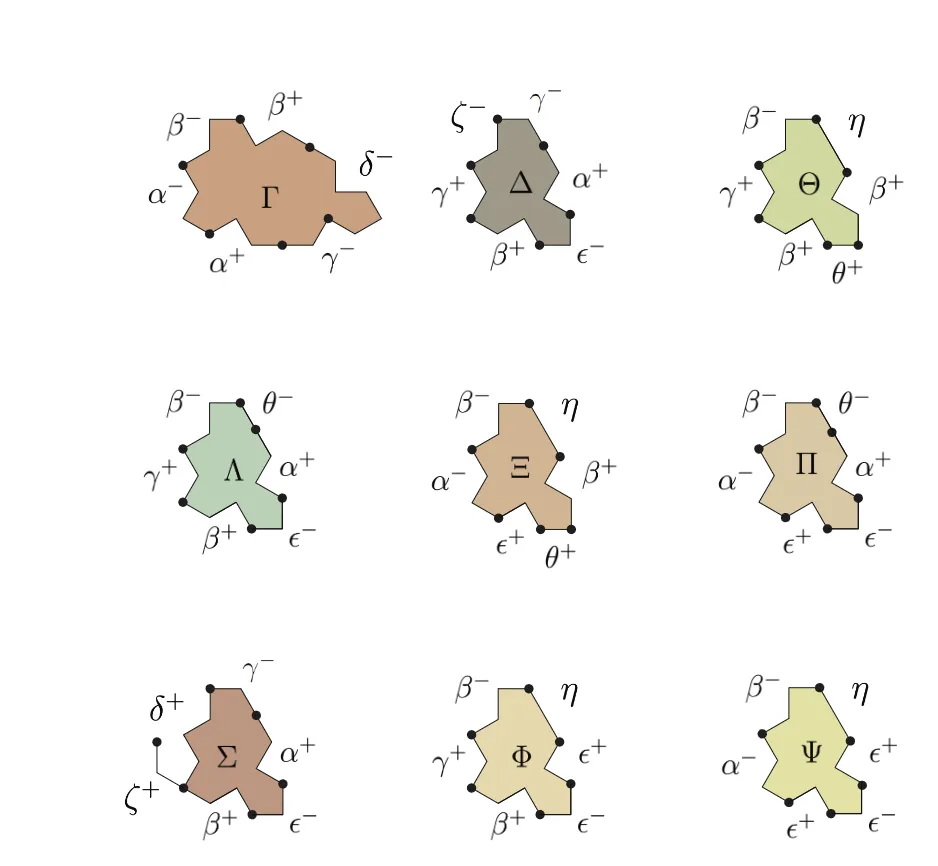

In [5]:
#@title Edge Class definition

# Translated from the diagram above.
# These match the hexagons but the values are repeated for as many
# spectre edges that are in the coresponding group.
# The starting point is the highest ofthe leftmost points).
# α (alpha) → 1
# β (beta) → 2
# γ (gamma) → 3
# δ (delta) → 4
# ε (epsilon) → 5
# ζ (zeta) → 6
# η (eta) → 0 (This is a straight line so there is no minus version)
# θ (theta) → 8
# Mystic internal edge → '7'

unique_edge_labels = {
    'Delta':  ['3.0A','3.1A', '2.0A','2.1A','2.2A', '-5.1A','-5.0A', '1.0A','1.1A','1.2A', '-3.1A','-3.0A', '-6.1A','-6.0A'],  # Δ
    'Theta':  ['3.0A','3.1A', '2.0A','2.1A','2.2A', '8.0A', '2.0B','2.1B','2.2B', '0.0A','0.1A', '-2.2A','-2.1A','-2.0A'],  # Θ
    'Lambda': ['3.0A','3.1A', '2.0A','2.1A','2.2A', '-5.1A','-5.0A', '1.0A','1.1A','1.2A', '-8.0A', '-2.2A','-2.1A','-2.0A'],  # Λ
    'Xi':     ['-1.2A','-1.1A','-1.0A', '5.0A','5.1A', '8.0A', '2.0A','2.1A','2.2A', '0.0A','0.1A', '-2.2A','-2.1A','-2.0A'],  # Ξ
    'Pi':     ['-1.2A','-1.1A','-1.0A', '5.0A','5.1A', '-5.1A','-5.0A', '1.0A','1.1A','1.2A', '-8.0A', '-2.2A','-2.1A','-2.0A'],  # Π
    'Sigma':  ['4.2A','4.3A', '2.0A','2.1A','2.2A', '-5.1A','-5.0A', '1.0A','1.1A','1.2A', '-3.1A','-3.0A', '4.0A','4.1A'],  # Σ
    'Phi':    ['3.0A','3.1A', '2.0A','2.1A','2.2A', '-5.1A','-5.0A', '5.0A','5.1A', '0.0A','0.1A', '-2.2A','-2.1A','-2.0A'],  # Φ
    'Psi':    ['-1.2A','-1.1A','-1.0A', '5.0A','5.1A', '-5.1A','-5.0A', '5.0B','5.1B', '0.0A','0.1A', '-2.2A','-2.1A','-2.0A'],  # Ψ
    'Gamma2': ['-7.1A','-7.0A', '-3.1A','-3.0A', '6.0A','6.1A', '-4.3A','-4.2A','-4.1A','-4.0A', '2.0A','2.1A', '-7.3A','-7.2A'],
    'Gamma1': ['-1.2A','-1.1A','-1.0A', '1.0A','1.1A','1.2A', '7.0A','7.1A','7.2A','7.3A', '2.2A', '-2.2A','-2.1A','-2.0A'],  # Γ
}

# The combo strings are aligned with this, so the string 1000000000 means the second option for Delta.
ALL_TILE_NAMES = ["Delta", "Theta", "Lambda", "Xi", "Pi", "Sigma", "Phi", "Psi", "Gamma2", "Gamma1"]

@total_ordering
@dataclass(frozen=True)
class Edge:
    """Represents a single edge in the Spectre tiling system"""
    major: int                          # The main edge type (1-8).
    is_negative: Optional[bool] = None  # Whether this is a negative edge. Could make this optional to represent either.
    minor: Optional[int] = None         # The subdivision of the edge (0.0-1.0), if applicable.
    variant: Optional[str] = None       # 'A' or 'B' variant, if applicable.
    pos: Optional[int] = None           # Position around the shape.

    @classmethod
    def from_string(cls, edge_str: str, in_pos=None) -> 'Edge':
        """Parse an edge string like '-5.1A' into an Edge object.
          in_pos: the position in the list above, which aligns with SPECTRE_POINTS.
        """
        pattern = r'^(-)?(\d+)(?:\.(\d+))?(A|B)?$'
        match = re.match(pattern, edge_str)
        if not match:
            raise ValueError(f"Invalid edge string format: {edge_str}")

        is_negative = bool(match.group(1))
        major = int(int(match.group(2)))
        minor = int(match.group(3)) if match.group(3) else None
        variant = match.group(4)
        pos = in_pos

        return cls(major, is_negative, minor, variant, pos)

    def __str__(self) -> str:
        """Convert edge back to string representation"""
        parts = []
        if self.is_negative:
            parts.append('-')
        parts.append(str(self.major))
        if self.minor is not None:
            parts.append(f".{self.minor}")
        if self.variant:
            parts.append(self.variant)
        return ''.join(parts)

    def __lt__(self, other):
      """Enable sorting of Edge objects"""
      if not isinstance(other, Edge):
          return NotImplemented
      return ((self.major, self.is_negative or False, self.minor or 0, self.variant or '') <
              (other.major, other.is_negative or False, other.minor or 0, other.variant or ''))

    def mask(self,  is_negative: bool = True,
             minor: bool = True, variant: bool = True) -> 'Edge':
        """
        Creates a new Edge with only the specified fields preserved.
        Other fields are set to None to act as wildcards in comparisons.

        Args:
            is_negative: If False, sets is_negative to None
            minor: If False, sets minor to None
            variant: If False, sets variant to None

        Returns:
            A new Edge instance with specified fields masked
        """
        return Edge(
            major=self.major, # Must have major. If I ever need to not have major I'll make it optional.
            is_negative=self.is_negative if is_negative else None,
            minor=self.minor if minor else None,
            variant=self.variant if variant else None
        )
    def entry_on_spectre(self) -> pt:
      """All lines come from the .1 minor (except 8) and leave through the middle
      except 0 which leaves between 0.0 and 0.1"""
      if self.pos is None:
        return None
      p1 = SPECTRE_POINTS[self.pos]
      if self.major != 0:
        p1 = midpoint(p1,SPECTRE_POINTS[(self.pos + 1) % len(SPECTRE_POINTS)])
      return p1

    def matches(self, other: 'Edge') -> bool:
        if self.major != other.major:
            return False
        if other.minor is not None and self.minor != other.minor:
            return False
        if other.is_negative is not None and self.is_negative != other.is_negative:
            return False
        if other.variant is not None and self.variant != other.variant:
            return False
        return True


@dataclass
class TileEdges:
    """Represents all edges for a specific tile type"""
    tile_type: str
    edges: List[Edge]


    @classmethod
    def from_edge_list(cls, tile_type: str, edge_strings: List[str]) -> 'TileEdges':
        """Create TileEdges from a list of edge string representations"""
        return cls(
            tile_type,
            [Edge.from_string(edge_str,in_pos=pos) for pos, edge_str in enumerate(edge_strings)]
        )

    def __iter__(self) -> Iterator[Edge]:
        return iter(self.edges)

    def __getitem__(self, idx):
        return self.edges[idx]

    def index(self, edge):
        """Return the index of edge in the edges list"""
        return self.edges.index(edge)


    def subset(self, match_edge: Edge) -> List[Edge]:
        return [match_edge for edge in self.edges if edge.matches(match_edge)]

    def major_edges(self):
        """Return the index of edge in the edges list"""
        majors = set(
            # Make minor None.
            e.mask(is_negative=True, minor=False, variant=True)
            for e in self.edges
        )
        # The shared 2 edge in Gamma1 shouldn't be counted. It's counted in Gamma2.
        if self.tile_type == 'Gamma1':
          majors -= set([Edge(major=2, is_negative=False, minor=None, variant='A')])
        return majors

    def major_edge_count(self):
        """Count of how many of each major edge (keyed by major int)"""
        ec = defaultdict(int)
        for edge in self.major_edges():
          ec[edge.major] += 1
        return ec

    def tails(self):
        """Which edges have tails lying around."""
        ec = set()
        for edge in self.major_edges():
          # If there is an even number then they can join up so remove it.
          if edge.major in ec:
            ec.remove(edge.major)
          else:
            ec.add(edge.major)
        return ec

    def connectable_edges(self):
        """is_connectable_edge defines what is possible"""
        return TileEdges(
            tile_type = self.tile_type,
            edges = [edge for edge in self.edges if is_connectable_edge(edge)],
        )

    def with_majors(self, major_set):
        return TileEdges(
            tile_type = self.tile_type,
            edges = [edge for edge in self.edges if edge.major in major_set],
        )

    def multiplicity_major(self, multiplicity):
        """multiplicity is a dict from major edge to how many lines go through it"""
        return {e:multiplicity[e.major] for e in create_tile_edges()['Delta'].major_edges() if e.major in multiplicity}

def is_connectable_edge(edge):
   """Check if edge can be connected (has minor=1 or major=8)."""
   return edge.minor == 1 or edge.major == 8

def create_tile_edges() -> Dict[str, TileEdges]:
    """Create TileEdges objects for all tile types"""
    return {
        tile_type: TileEdges.from_edge_list(tile_type, edge_list)
        for tile_type, edge_list in unique_edge_labels.items()
    }


def get_edge_labels(tile_type: str) -> TileEdges:
    """Get edges for a specific tile type"""
    tile_edges = create_tile_edges()
    return tile_edges[tile_type]


def make_tails_df():
  tile_edges = create_tile_edges()
  data = {}
  for tile_name, tile in tile_edges.items():
    row = defaultdict(lambda: 0)
    ec = tile.major_edge_count()
    print(ec)
    for tail in range(9):
      # row[tail] = 1 if tail in tile.tails() else 0
      row[tail] = ec[tail]# if tail in ec else 0
    data[tile_name] = row
  df = pd.DataFrame.from_dict(data, orient='index')
  return df

In [6]:
make_tails_df()

defaultdict(<class 'int'>, {6: 1, 3: 2, 5: 1, 1: 1, 2: 1})
defaultdict(<class 'int'>, {2: 3, 8: 1, 3: 1, 0: 1})
defaultdict(<class 'int'>, {3: 1, 5: 1, 1: 1, 2: 2, 8: 1})
defaultdict(<class 'int'>, {1: 1, 8: 1, 5: 1, 0: 1, 2: 2})
defaultdict(<class 'int'>, {1: 2, 5: 2, 2: 1, 8: 1})
defaultdict(<class 'int'>, {3: 1, 5: 1, 1: 1, 4: 1, 2: 1})
defaultdict(<class 'int'>, {3: 1, 5: 2, 0: 1, 2: 2})
defaultdict(<class 'int'>, {1: 1, 5: 3, 0: 1, 2: 1})
defaultdict(<class 'int'>, {7: 1, 3: 1, 4: 1, 6: 1, 2: 1})
defaultdict(<class 'int'>, {1: 2, 7: 1, 2: 1})


,0,1,2,3,4,5,6,7,8
Delta,0,1,1,2,0,1,1,0,0
Theta,1,0,3,1,0,0,0,0,1
Lambda,0,1,2,1,0,1,0,0,1
Xi,1,1,2,0,0,1,0,0,1
Pi,0,2,1,0,0,2,0,0,1
Sigma,0,1,1,1,1,1,0,0,0
Phi,1,0,2,1,0,2,0,0,0
Psi,1,1,1,0,0,3,0,0,0
Gamma2,0,0,1,1,1,0,1,1,0
Gamma1,0,2,1,0,0,0,0,1,0


In [7]:
#@title The guts of the algorithms
# Adapted from https://github.com/shrx/spectre/blob/master/spectre.py

import drawsvg as draw
import numpy as np
from time import time

num_tiles = 0

IDENTITY = [1, 0, 0, 0, 1, 0]

TILE_NAMES = ["Gamma", "Delta", "Theta", "Lambda", "Xi", "Pi", "Sigma", "Phi", "Psi"]

COLOR_MAP_ORIG = {
    "Gamma":  "rgb(255, 255, 255)",
    "Gamma1": "rgb(255, 255, 255)",
    "Gamma2": "rgb(255, 255, 255)",
    "Delta":  "rgb(220, 220, 220)",
    "Theta":  "rgb(255, 191, 191)",
    "Lambda": "rgb(255, 160, 122)",
    "Xi":     "rgb(255, 242, 0)",
    "Pi":     "rgb(135, 206, 250)",
    "Sigma":  "rgb(245, 245, 220)",
    "Phi":    "rgb(0,   255, 0)",
    "Psi":    "rgb(0,   255, 255)"
}

COLOR_MAP_MYSTICS = {
    "Gamma":  "rgb(196, 201, 169)",
    "Gamma1": "rgb(196, 201, 169)",
    "Gamma2": "rgb(156, 160, 116)",
    "Delta":  "rgb(247, 252, 248)",
    "Theta":  "rgb(247, 252, 248)",
    "Lambda": "rgb(247, 252, 248)",
    "Xi":     "rgb(247, 252, 248)",
    "Pi":     "rgb(247, 252, 248)",
    "Sigma":  "rgb(247, 252, 248)",
    "Phi":    "rgb(247, 252, 248)",
    "Psi":    "rgb(247, 252, 248)"
}

COLOR_MAP = COLOR_MAP_ORIG

SPECTRE_POINTS = [
    pt(0,                0),
    pt(1.0,              0.0),
    pt(1.5,              -np.sqrt(3)/2),
    pt(1.5+np.sqrt(3)/2, 0.5-np.sqrt(3)/2),
    pt(1.5+np.sqrt(3)/2, 1.5-np.sqrt(3)/2),
    pt(2.5+np.sqrt(3)/2, 1.5-np.sqrt(3)/2),
    pt(3+np.sqrt(3)/2,   1.5),
    pt(3.0,              2.0),
    pt(3-np.sqrt(3)/2,   1.5),
    pt(2.5-np.sqrt(3)/2, 1.5+np.sqrt(3)/2),
    pt(1.5-np.sqrt(3)/2, 1.5+np.sqrt(3)/2),
    pt(0.5-np.sqrt(3)/2, 1.5+np.sqrt(3)/2),
    pt(-np.sqrt(3)/2,    1.5),
    pt(0.0,              1.0)
]

SPECTRE_SHAPE = draw.Lines(*flatten([p.xy for p in SPECTRE_POINTS]), close=True)

Centerpoint = pt(1.5, 1.0)
def drawPolygon(drawing, T, label, functions=None):
    """
    Draw a polygon with transformation and accepts a list of drawing functions

    Args:
        drawing: The drawing object to append to
        T: Transformation matrix
        label: The tile label
        functions: List of functions that each accept (group, label) as arguments
    """
    group = draw.Group(
        transform=f"matrix({T[0]} {T[3]} {T[1]} {T[4]} {T[2]} {T[5]})"
    )

    # Apply each drawing function
    if functions:
        for func in functions:
            func(group, label, T)

    drawing.append(group)

# Then define the individual drawing functions:
def draw_base(group, label, _):
    group.append(draw.Use(
        SPECTRE_SHAPE,
        0, 0,
        fill=COLOR_MAP[label],
        stroke="black",
        stroke_width=0.1))

def draw_center_text(group, label, _):
    group.append(draw.Text(
        label,
        .4,
        1.5, 1.0,
        text_anchor="middle",
        fill="black",
        dominant_baseline="middle"
    ))

def draw_edge_numbers(group, label, _):
    edge_labels = get_edge_labels(label)
    for i in range(len(SPECTRE_POINTS)):
        p1 = SPECTRE_POINTS[i]
        p2 = SPECTRE_POINTS[(i + 1) % len(SPECTRE_POINTS)]
        label_x, label_y = get_inset_point(p1, p2)
        elab = str(edge_labels[i])
        group.append(draw.Text(
            elab,
            0.15, # .22
            label_x, label_y,
            text_anchor="middle",
            fill="red" if '-' in elab else "blue",
            dominant_baseline="middle"
        ))

def check_edge_pair_conditions(pair, minor_edge_selector=1):
    """Check if edge pair meets the minor edge or major 8 conditions."""
    return (
        is_connectable_edge(pair[0]) and is_connectable_edge(pair[1])
      )

def is_connectable_edge(edge):
   """Check if edge can be connected (has minor=1 or major=8)."""
   return edge.minor == 1 or edge.major == 8

def make_edge_graph(big_edge_graph, T, face, allowed_edges=None):
    """Create graph edges for a tile, similar to drawPolygon. TODO prefilter for allowed_edges"""

    # Get transformed points
    transformed_points = [transPt(T, p) for p in SPECTRE_POINTS]

    # Add edges using edge labels
    edges = get_edge_labels(face)
    face_point = transPt(T, pt(1.5,1))

    face_label = f"{face}:[{round(face_point.x*10,3)},{round(face_point.y*10,3)}]"

    for i in range(len(SPECTRE_POINTS)):
        pA = transformed_points[i]
        pAuse = pA
        if edges[i].major != 0:
          pA2 = transformed_points[(i+1) % len(SPECTRE_POINTS)]
          pAuse = midpoint(pA,pA2)
        p1_key = (round(pAuse.x*10,3), round(pAuse.y*10,3))
        for i2 in range(len(SPECTRE_POINTS)):
          if i2 <= i:
            continue

          edge_pair = (edges[i], edges[i2])
          # Filter the edge pair before adding
          # This filters for only .1's except 8's which only have 1 edge.
          if check_edge_pair_conditions(edge_pair):
            pB = transformed_points[i2]
            pBuse = pB
            if edges[i2].major != 0:
              pB2 = transformed_points[(i2+1) % len(SPECTRE_POINTS)]
              pBuse = midpoint(pB,pB2)
            p2_key = (round(pBuse.x*10,3), round(pBuse.y*10,3))
            big_edge_graph.setdefault(p1_key, {}).setdefault(p2_key, {}).setdefault(face_label, []).append(edge_pair)

class Tile:
    def __init__(self, pts, label):
        """
        pts: list of Tile coordinate points
        label: Tile type used for coloring
        """
        self.quad = [pts[3], pts[5], pts[7], pts[11]]
        self.label = label

    def draw(self, drawing, tile_transformation=IDENTITY, draw_funcs=None):
        global num_tiles
        num_tiles += 1
        return drawPolygon(drawing, tile_transformation, self.label, draw_funcs)

    def make_edge_graph(self, big_edge_graph, tile_transformation=IDENTITY, allowed_edges=None):
        make_edge_graph(big_edge_graph, tile_transformation, self.label, allowed_edges=allowed_edges)

class MetaTile:
    def __init__(self, geometries=[], quad=[]):
        """
        geometries: list of pairs of (Meta)Tiles and their transformations
        quad: MetaTile quad points
        """
        self.geometries = geometries
        self.quad = quad

    def draw(self, drawing, metatile_transformation=IDENTITY,draw_funcs=None):
        """
        recursively expand MetaTiles down to Tiles and draw those
        """
        # TODO: parallelize?
        [ shape.draw(drawing, mul(metatile_transformation, shape_transformation), draw_funcs) for shape, shape_transformation in self.geometries ]

    def make_edge_graph(self, big_edge_graph, metatile_transformation=IDENTITY,allowed_edges=None):
        for shape, shape_transformation in self.geometries:
            shape.make_edge_graph(big_edge_graph, mul(metatile_transformation, shape_transformation), allowed_edges=allowed_edges)

def draw_shape(shape_data):
    drawing, metatile_transformation, shape, shape_transformation = shape_data
    return shape.draw(drawing, mul(metatile_transformation, shape_transformation))

def buildSpectreBase():
    spectre_base_cluster = { label: Tile(SPECTRE_POINTS, label) for label in TILE_NAMES if label != "Gamma" }
    # special rule for Gamma
    mystic = MetaTile(
        [
            [Tile(SPECTRE_POINTS, "Gamma1"), IDENTITY],
            [Tile(SPECTRE_POINTS, "Gamma2"), mul(ttrans(SPECTRE_POINTS[8].x, SPECTRE_POINTS[8].y), trot(np.pi/6))]
        ],
        [SPECTRE_POINTS[3], SPECTRE_POINTS[5], SPECTRE_POINTS[7], SPECTRE_POINTS[11]]
    )
    spectre_base_cluster["Gamma"] = mystic

    return spectre_base_cluster

# This is where the magic happens.
def buildSupertiles(tileSystem):
    """
    iteratively build on current system of tiles
    tileSystem = current system of tiles, initially built with buildSpectreBase()
    """

    # First, use any of the nine-unit tiles in tileSystem to obtain
    # a list of transformation matrices for placing tiles within
    # supertiles.
    quad = tileSystem["Delta"].quad
    R = [-1, 0, 0, 0, 1, 0]

    """
    [rotation angle, starting quad point, target quad point]
    """
    transformation_rules = [
        [60, 3, 1], [0, 2, 0], [60, 3, 1], [60, 3, 1],
        [0, 2, 0], [60, 3, 1], [-120, 3, 3]
    ]

    transformations = [IDENTITY]
    total_angle = 0
    rotation = IDENTITY
    transformed_quad = list(quad)

    for _angle, _from, _to in transformation_rules:
        if(_angle != 0):
            total_angle += _angle
            rotation = trot(np.deg2rad(total_angle))
            transformed_quad = [ transPt(rotation, quad_pt) for quad_pt in quad ]

        ttt = transTo(
            transformed_quad[_to],
            transPt(transformations[-1], quad[_from])
        )
        transformations.append(mul(ttt, rotation))

    transformations = [ mul(R, transformation) for transformation in transformations ]

    # Now build the actual supertiles, labelling appropriately.
    super_rules = {
        "Gamma":  ["Pi",  "Delta", None,  "Theta", "Sigma", "Xi",  "Phi",    "Gamma"],
        "Delta":  ["Xi",  "Delta", "Xi",  "Phi",   "Sigma", "Pi",  "Phi",    "Gamma"],
        "Theta":  ["Psi", "Delta", "Pi",  "Phi",   "Sigma", "Pi",  "Phi",    "Gamma"],
        "Lambda": ["Psi", "Delta", "Xi",  "Phi",   "Sigma", "Pi",  "Phi",    "Gamma"],
        "Xi":     ["Psi", "Delta", "Pi",  "Phi",   "Sigma", "Psi", "Phi",    "Gamma"],
        "Pi":     ["Psi", "Delta", "Xi",  "Phi",   "Sigma", "Psi", "Phi",    "Gamma"],
        "Sigma":  ["Xi",  "Delta", "Xi",  "Phi",   "Sigma", "Pi",  "Lambda", "Gamma"],
        "Phi":    ["Psi", "Delta", "Psi", "Phi",   "Sigma", "Pi",  "Phi",    "Gamma"],
        "Psi":    ["Psi", "Delta", "Psi", "Phi",   "Sigma", "Psi", "Phi",    "Gamma"]
    }
    super_quad = [
        transPt(transformations[6], quad[2]),
        transPt(transformations[5], quad[1]),
        transPt(transformations[3], quad[2]),
        transPt(transformations[0], quad[1])
    ]

    return {
        label: MetaTile(
            [ [tileSystem[substitution], transformation] for substitution, transformation in zip(substitutions, transformations) if substitution ],
            super_quad
        ) for label, substitutions in super_rules.items() }

supertiling loop took 0.0021 seconds
tile recursion loop took 0.1624 seconds, generated 4401 tiles
SVG drawing took 0.2454 seconds
total processing time 0.4099 seconds, 93.139 μs/tile


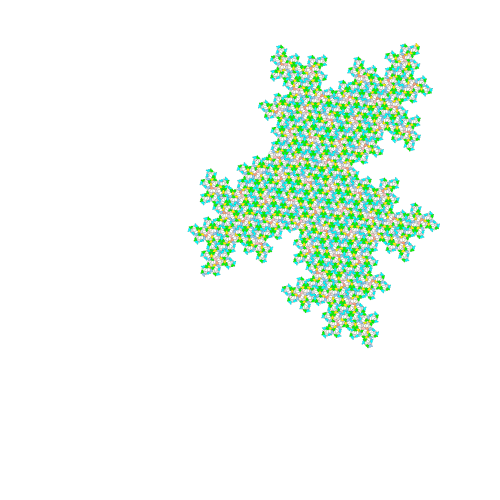

In [8]:
N_ITERATIONS = 4
start = time()
shapes = buildSpectreBase()
for _ in range(N_ITERATIONS):
    shapes = buildSupertiles(shapes)
time1 = time()-start
print(f"supertiling loop took {round(time1, 4)} seconds")

d = draw.Drawing(500, 500, origin="center")

start = time()
shapes["Delta"].draw(d,draw_funcs=[draw_base])
time2 = time()-start
print(f"tile recursion loop took {round(time2, 4)} seconds, generated {num_tiles} tiles")

start = time()
d.save_svg("spectre.svg")
time3 = time()-start
print(f"SVG drawing took {round(time3, 4)} seconds")
print(f"total processing time {round(time1+time2+time3, 4)} seconds, {round(1000000*(time1+time2+time3)/num_tiles, 4)} μs/tile")
d

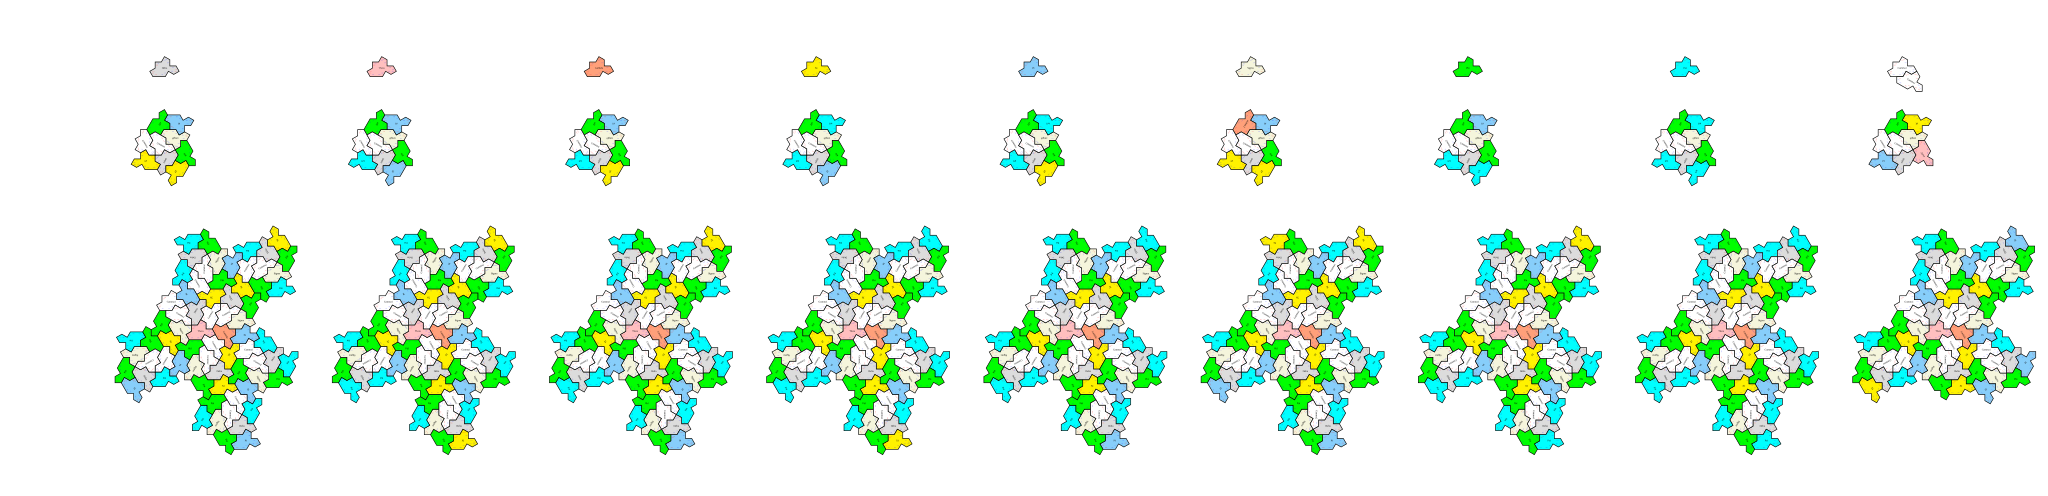

In [9]:
#@title Draw 3 iterations of expansion for each tile type.



def scale_drawing(d, scale_factor=1.5, offset=None):
    """
    Scale an entire drawing by applying a matrix transform.

    Args:
        d: Drawing to scale
        scale_factor: Amount to scale by
        offset_x: X offset after scaling
        offset_y: Y offset after scaling
    """
    if offset is None:
        offset_x = 0
        offset_y = 0
    else:
        offset_x, offset_y = offset
    matrix = f'matrix({scale_factor} 0 0 {scale_factor} {offset_x} {offset_y})'

    scaled = draw.Group(transform=matrix)
    for elem in d.elements:
        scaled.append(elem)

    new_d = draw.Drawing(
        d.width,
        d.height,
        origin="center"
    )
    new_d.append(scaled)
    return new_d


def save_drawing(d, name="blerg"):
    # Create a temporary file
    # with tempfile.NamedTemporaryFile(suffix='.svg', delete=False) as tmp:
    temp_filename = f'/content/{name}.svg'
    with open(temp_filename, 'w') as tmp:
      d.save_svg(temp_filename)

    # Read the SVG file content
    with open(temp_filename, 'r') as f:
        svg_content = f.read()
        return svg_content



# For drawing the reference tile grid.
def get_tile_transforms():
    tile_types = ["Delta", "Theta", "Lambda", "Xi", "Pi", "Sigma", "Phi", "Psi", "Gamma"]
    transforms = {}
    scale_factor=30
    spacing = 5  # Horizontal
    for i, tile_type in enumerate(tile_types):
        # Calculate base transform
        start_x = -((len(tile_types) - 1) * spacing) * 0.5 + 8
        extra = -5 if i < 5 else 2
        # mul(ttrans(SPECTRE_POINTS[8].x, SPECTRE_POINTS[8].y), trot(np.pi/6))
        transform = np.array([1, 0, start_x + (i%5 * spacing), 0, 1, extra])*scale_factor
        transforms[tile_type] = transform
    return transforms

def draw_tile_grid(draw_funcs):
  d = draw.Drawing(800, 600, origin="center")
  shapes = buildSpectreBase()
  transforms = get_tile_transforms()
  for tile_type, transform in transforms.items():
      shapes[tile_type].draw(d, transform, draw_funcs)
  return d


def draw_tile(tile_type, draw_funcs):
  d = draw.Drawing(200, 200, origin="center")
  shapes = buildSpectreBase()
  scale_factor=30
  transform = np.array([1, 0, -2, 0, 1, 0])*scale_factor
  shapes[tile_type].draw(d, transform, draw_funcs)
  return d

def draw_big_tile_grid(draw_funcs=None):
   d = draw.Drawing(3300, 800, origin="center")

   # Layout in a single row
   tile_types = ["Delta", "Theta", "Lambda", "Xi", "Pi", "Sigma", "Phi", "Psi", "Gamma"]
   spacing = 35  # Horizontal spacing between tiles

   shapes = buildSpectreBase()
   shapes2 = buildSupertiles(shapes)
   shapes3 = buildSupertiles(shapes2)

   # Calculate starting x to center the row
   start_x = -((len(tile_types) - 1) * spacing) *0.5

   if draw_funcs is None:
     draw_funcs = [draw_base, draw_center_text, draw_edge_numbers]

   for i, tile_type in enumerate(tile_types):
       # First iteration.
       translate = [1, 0, start_x + (i * spacing), 0, 1, -30]
       shapes[tile_type].draw(d, translate, draw_funcs=draw_funcs)
       # Second iteration.
       translate = [1, 0, start_x + (i * spacing), 0, 1, 15-30]
       shapes2[tile_type].draw(d, translate, draw_funcs=draw_funcs)
       # Third iteration.
       translate = [1, 0, start_x + (i * spacing), 0, 1, 15*2-10]
       shapes3[tile_type].draw(d, translate, draw_funcs=draw_funcs)

   m = scale_drawing(d, scale_factor=10)
   save_drawing(m, name="All expansions")
   display(m)
   return m

# Seriously, try and line these up in inkscape or print and cut them out,
# it's harder than you'd think. The flipping is very confusing but makes sense eventually.
draw_big_tile_grid()
print() # So it doesn't display twice.

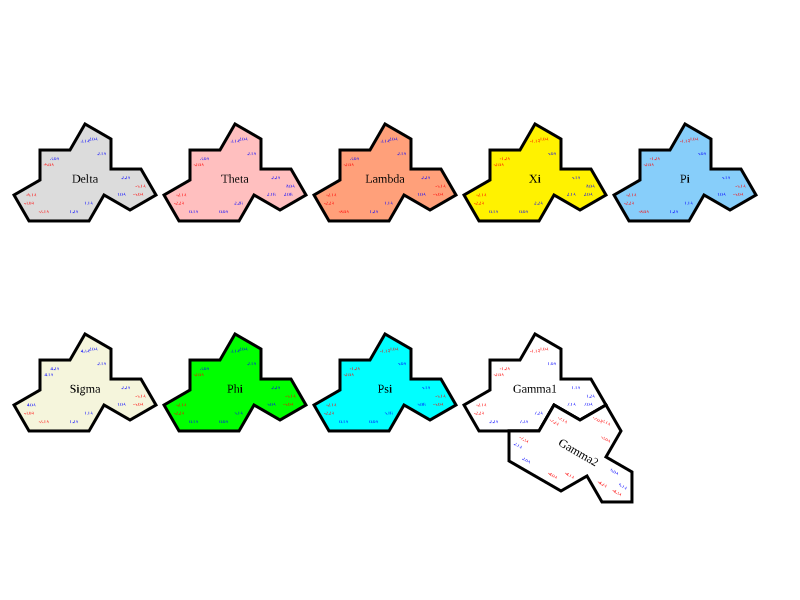

In [10]:
d = draw_tile_grid(draw_funcs=[draw_base, draw_center_text, draw_edge_numbers])
d

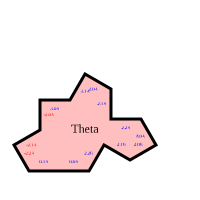

In [11]:
# Handy for debugging.
draw_tile('Theta', draw_funcs=[draw_base, draw_center_text, draw_edge_numbers])

# Solving the tails problem

In [12]:

# This demonstrates the tails problem.
def draw_lines_in_from_edges(selected_edges):
    def inner(group, label, _):
        edge_labels = get_edge_labels(label)
        for edge in edge_labels.connectable_edges():
            if edge.major in selected_edges:
                p1 = SPECTRE_POINTS[edge.pos]
                p2 = SPECTRE_POINTS[(edge.pos + 1) % len(SPECTRE_POINTS)]
                mid_edge = midpoint(p1,p2)
                between_center = midpoint(Centerpoint,mid_edge)
                group.append(draw.Line(
                    between_center.x, between_center.y,
                    mid_edge.x, mid_edge.y,
                    stroke="black",
                    stroke_width=0.02
                ))
    return inner

In [13]:
tails = make_tails_df()
print((tails  @ edge_vec({3,5})).to_markdown())

defaultdict(<class 'int'>, {6: 1, 3: 2, 5: 1, 1: 1, 2: 1})
defaultdict(<class 'int'>, {2: 3, 8: 1, 3: 1, 0: 1})
defaultdict(<class 'int'>, {3: 1, 5: 1, 1: 1, 2: 2, 8: 1})
defaultdict(<class 'int'>, {1: 1, 8: 1, 5: 1, 0: 1, 2: 2})
defaultdict(<class 'int'>, {1: 2, 5: 2, 2: 1, 8: 1})
defaultdict(<class 'int'>, {3: 1, 5: 1, 1: 1, 4: 1, 2: 1})
defaultdict(<class 'int'>, {3: 1, 5: 2, 0: 1, 2: 2})
defaultdict(<class 'int'>, {1: 1, 5: 3, 0: 1, 2: 1})
defaultdict(<class 'int'>, {7: 1, 3: 1, 4: 1, 6: 1, 2: 1})
defaultdict(<class 'int'>, {1: 2, 7: 1, 2: 1})
|        |   0 |
|:-------|----:|
| Delta  |   3 |
| Theta  |   1 |
| Lambda |   2 |
| Xi     |   1 |
| Pi     |   2 |
| Sigma  |   2 |
| Phi    |   3 |
| Psi    |   3 |
| Gamma2 |   1 |
| Gamma1 |   0 |


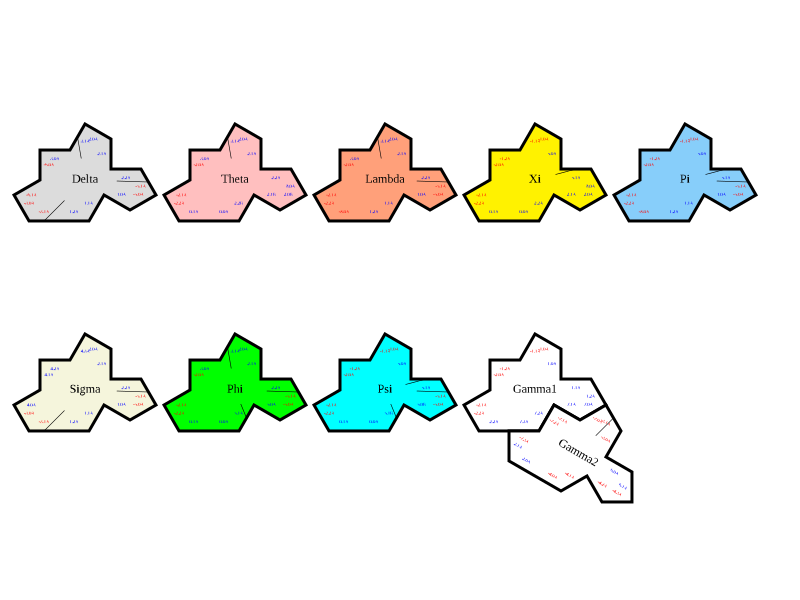

,0
Delta,3
Theta,1
Lambda,2
Xi,1
Pi,2
Sigma,2
Phi,3
Psi,3
Gamma2,1
Gamma1,0


In [14]:
# Provide some edges and see how it plays out.
selected_edges={3,5}
d = draw_tile_grid(draw_funcs=[draw_base, draw_center_text, draw_edge_numbers, draw_lines_in_from_edges(selected_edges)])
display(d)
save_drawing(d, '35_ref')
tails @ edge_vec(selected_edges)

In [15]:
print(tails.to_markdown())

|        |   0 |   1 |   2 |   3 |   4 |   5 |   6 |   7 |   8 |
|:-------|----:|----:|----:|----:|----:|----:|----:|----:|----:|
| Delta  |   0 |   1 |   1 |   2 |   0 |   1 |   1 |   0 |   0 |
| Theta  |   1 |   0 |   3 |   1 |   0 |   0 |   0 |   0 |   1 |
| Lambda |   0 |   1 |   2 |   1 |   0 |   1 |   0 |   0 |   1 |
| Xi     |   1 |   1 |   2 |   0 |   0 |   1 |   0 |   0 |   1 |
| Pi     |   0 |   2 |   1 |   0 |   0 |   2 |   0 |   0 |   1 |
| Sigma  |   0 |   1 |   1 |   1 |   1 |   1 |   0 |   0 |   0 |
| Phi    |   1 |   0 |   2 |   1 |   0 |   2 |   0 |   0 |   0 |
| Psi    |   1 |   1 |   1 |   0 |   0 |   3 |   0 |   0 |   0 |
| Gamma2 |   0 |   0 |   1 |   1 |   1 |   0 |   1 |   1 |   0 |
| Gamma1 |   0 |   2 |   1 |   0 |   0 |   0 |   0 |   1 |   0 |


In [16]:
# Use this to test the effect of having different subsets.
(tails.values @ edge_vec({1}) )

array([1, 0, 1, 1, 2, 1, 0, 1, 0, 2])

In [19]:
# How many tails will each tile have for using these edges?
# Same as above but mod 2.
(tails.values @ edge_vec({1}) )%2

array([1, 0, 1, 1, 0, 1, 0, 1, 0, 0])

In [20]:
# Construct a dictionary mapping the resulting tails to the sets that generate that result.
# We will combine keys/values to build the complete set of possible tails.
all_rows_seen = defaultdict(list)
for i, row in enumerate(tails.values.T):
    all_rows_seen[list_to_str(row%2)].append({i})
all_rows_seen

defaultdict(list,
            {'0101001100': [{0}],
             '1011010100': [{1}, {5}],
             '1100110111': [{2}],
             '0110011010': [{3}],
             '0000010010': [{4}],
             '1000000010': [{6}],
             '0000000011': [{7}],
             '0111100000': [{8}]})

In [21]:
%%time
found_any = True
# We will check separately for the subset that is the intersection.
# So ignore anything that has an intersection.
# i.e don't add {0, 3, 4, 7, 8} to [{3}], because we will separately
# consider {0, 4, 7, 8}.
# If we didn't add this intersection check every entry would end up
# With the complete preimage of that value (key e.g. 1001101010).
# Instead we build a minimal group based on the keys and then try
# all the combinations of substitutions.
# This is a valid approach, but much slower. Set 'comprehensive' to True
# To experiment with this approach.
comprehensive =False
while found_any:
  new_all_rows_seen = all_rows_seen.copy()
  found_any = False
  for res1, all_inputs1 in all_rows_seen.items():
    for res2, all_inputs2 in all_rows_seen.items():
      # Add together the results.
      l1 = str_to_array(res1)
      l2 = str_to_array(res2)
      lr = (l1+l2)%2
      for inputs1 in all_inputs1:
        for inputs2 in all_inputs2:
          if not comprehensive and inputs1.intersection(inputs2):
            continue
          lrs = list_to_str(lr)
          both = inputs1.symmetric_difference(inputs2)
          for ll in new_all_rows_seen[lrs]:
            if ll == both or (not comprehensive and len(ll.intersection(both))>0):
              break
          else:
            new_all_rows_seen[lrs].append(both)
            found_any = True
  all_rows_seen = new_all_rows_seen

all_rows_seen

CPU times: user 130 ms, sys: 1.18 ms, total: 132 ms
Wall time: 345 ms


defaultdict(list,
            {'0101001100': [{0}, {1, 3, 6}],
             '1011010100': [{1}, {5}, {0, 3, 6}, {2, 7, 8}],
             '1100110111': [{2}, {1, 7, 8}],
             '0110011010': [{3}, {0, 1, 6}],
             '0000010010': [{4}],
             '1000000010': [{6}, {0, 1, 3}],
             '0000000011': [{7}, {1, 2, 8}],
             '0111100000': [{8}, {1, 2, 7}],
             '1110011000': [{0, 1}, {3, 6}],
             '1001111011': [{0, 2}, {3, 6, 7, 8}],
             '0011010110': [{0, 3}, {1, 6}],
             '0101011110': [{0, 4}],
             '1101001110': [{0, 6}, {1, 3}],
             '0101001111': [{0, 7}, {2, 3, 6, 8}],
             '0010101100': [{0, 8}, {2, 3, 6, 7}],
             '0000000000': [{1, 5}, {0, 2, 3, 6, 7, 8}],
             '0111100011': [{1, 2}, {7, 8}],
             '1011000110': [{1, 4}],
             '1011010111': [{1, 7}, {2, 8}],
             '1100110100': [{1, 8}, {2, 7}],
             '1010101101': [{2, 3}, {0, 6, 7, 8}],
            

In [22]:
all_rows_seen['0000000000']

[{1, 5}, {0, 2, 3, 6, 7, 8}]

In [23]:
sets = all_rows_seen['0000000000']
kernel = set(['']) # set of sorted string sets.
for s in sets:
  kernel.add(set_to_str(s))
kernel

{'', '023678', '15'}

In [24]:
possible_replacements ={}#defaultdict(str)
for r, ss in all_rows_seen.items():
  for s in ss:
    sm = list_to_str(sorted(list(s)))
    possible_replacements[sm]=[sa for sa in ss if sa != s]


def expand(exp_set, kernel):
  new_stuff = set()
  for s in exp_set:
    for c in str_to_set(s):
      # Try and replace c in s with its possible replacements.
      new_set = str_to_set(s).difference(set([c]))
      for rep in possible_replacements[str(c)]:
        # Don't include things that are already there.
        u = new_set.symmetric_difference(rep)
        if set([c]) == rep or rep.issubset(new_set) or set_to_str(u) in kernel:
          continue
        new_stuff.add(set_to_str(u))
  return new_stuff.union(kernel)

In [25]:
expanded= {}
while len(expanded) != len(kernel):
  kernel = kernel.union(expanded)
  expanded = expand(kernel, kernel)

In [26]:
# Merge all elements to make sure we have all combintations.
import itertools
for pair in itertools.combinations(kernel, 2):
  u = set_to_str(str_to_set(pair[0]).symmetric_difference(str_to_set(pair[1])))
  if u not in kernel:
    kernel.add(u)

In [27]:
# It is important to consider all entries because while the tails whatever
# can be decomposed, there are combinations that change the overall structure
# with interactions between subsets, e.g. maybe a pattern in 01235678 has an
# edge between a 1 - 5 and a 5 - 0. So while this may be a valid basis you need
# the whole space to generate every possible edge pairing.
basis = { '0356', '1278', '15'}
kernel

{'', '01235678', '0136', '023678', '0356', '1278', '15', '2578'}

set()


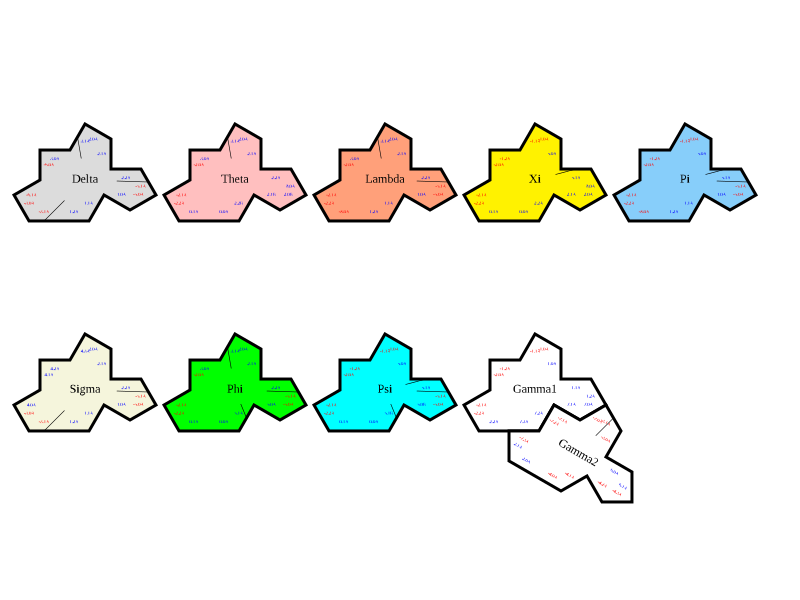

{np.int64(8), np.int64(1), np.int64(2), np.int64(7)}


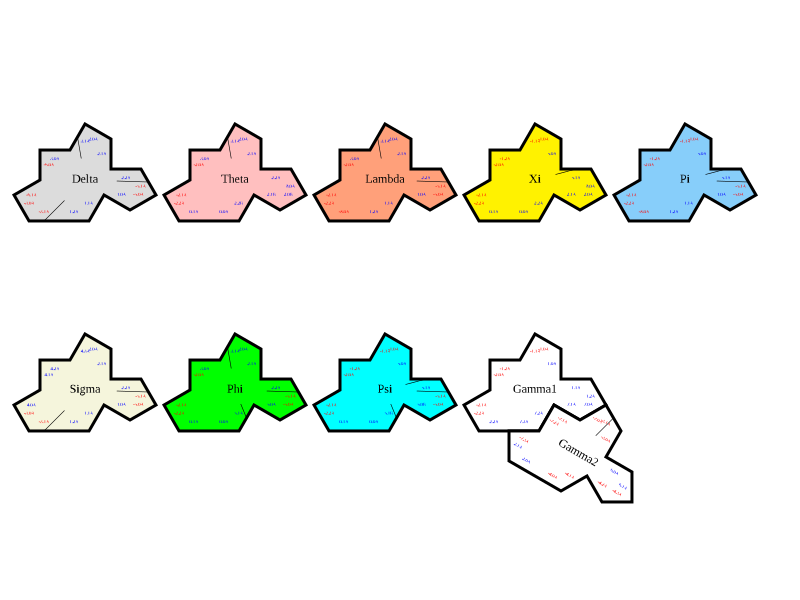

{np.int64(0), np.int64(3), np.int64(5), np.int64(6)}


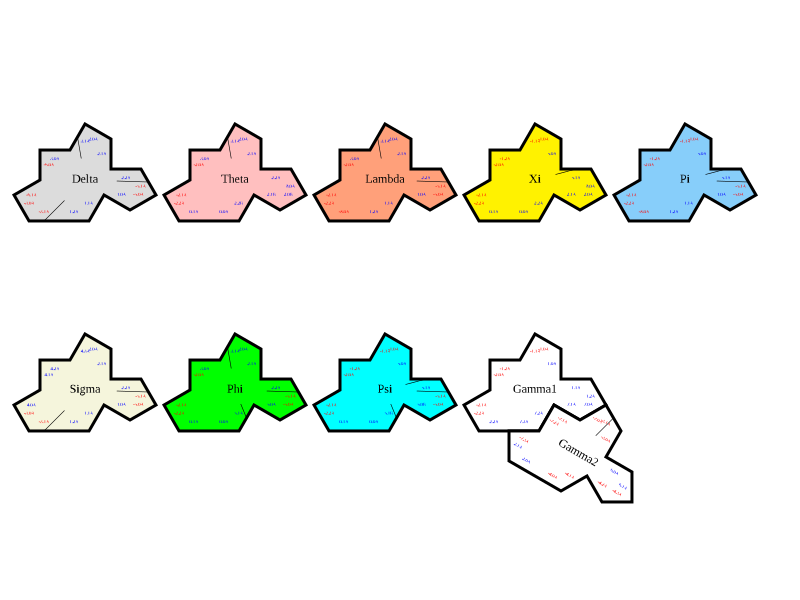

{np.int64(8), np.int64(2), np.int64(5), np.int64(7)}


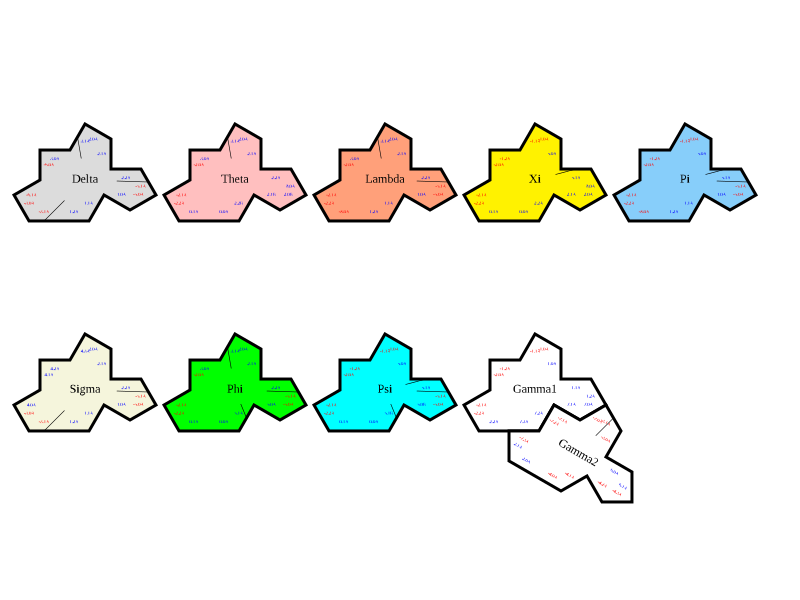

{np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8)}


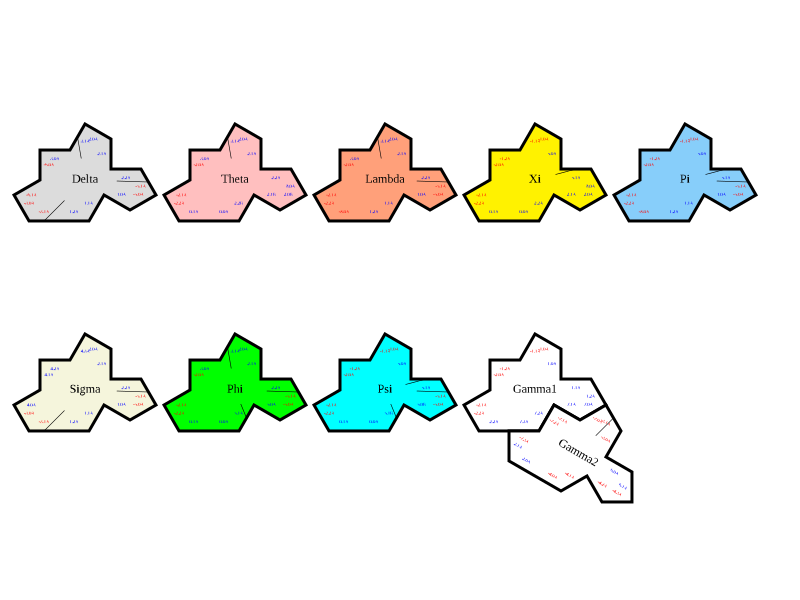

{np.int64(0), np.int64(2), np.int64(3), np.int64(6), np.int64(7), np.int64(8)}


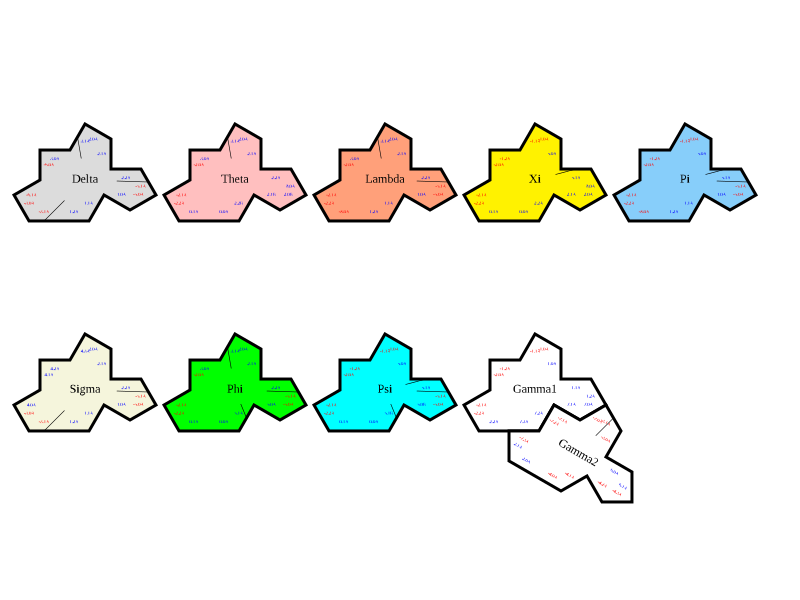

{np.int64(1), np.int64(5)}


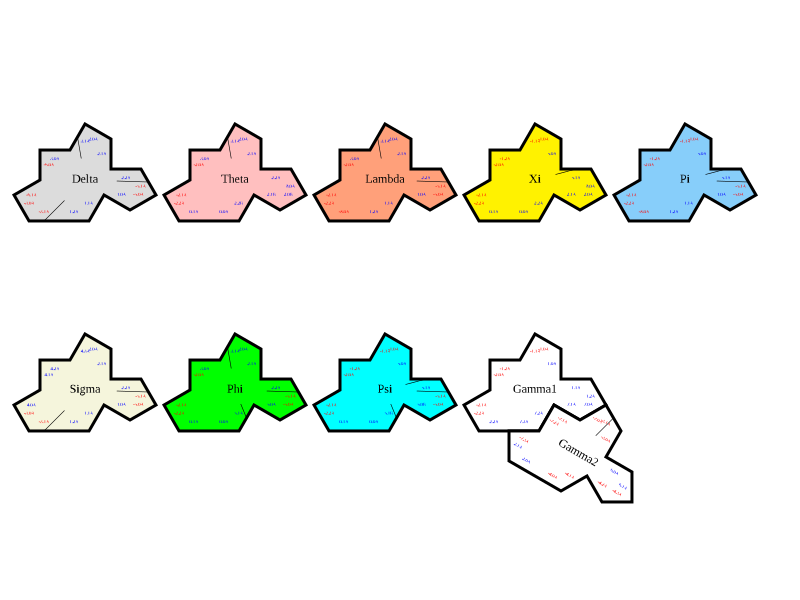

{np.int64(0), np.int64(1), np.int64(3), np.int64(6)}


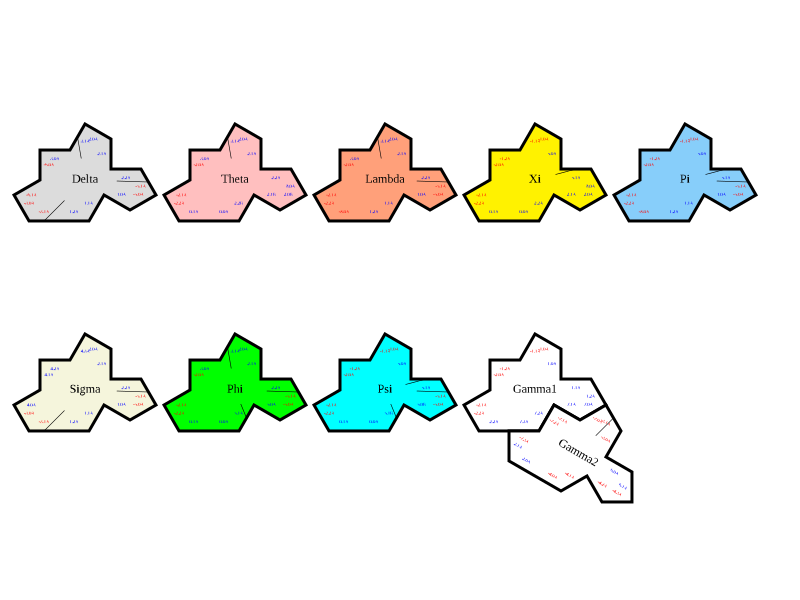

In [28]:
for kern_vec in kernel:
  kvs = str_to_set(kern_vec)
  print(kvs)
  d = draw_tile_grid(draw_funcs=[draw_base, draw_center_text, draw_edge_numbers, draw_lines_in_from_edges(selected_edges)])
  display(d)

In [29]:
#@title more funcs ..

def val_counts(stuff):
  counts = {}
  for x in stuff:
    if x not in counts:
      counts[x] = 0
    counts[x] += 1
  return counts


def val_count_key(vc):
  s = ""
  for k in sorted(vc.keys()):
    v = vc[k]
    s += f"{k}:{v},"
  return s[:-1]


def filter_results(subcombos):
  """Uses the value_counts of the major edge occurances to make a unique key"""
  result = []
  seen_combos = set()
  for subcombo in subcombos:
      vc = val_count_key(val_counts(subcombo))
      if vc not in seen_combos:
          seen_combos.add(vc)
          result.append(subcombo)
  return result

def generate_valid_combinations(counts):
    if all(v == 0 for v in counts.values()):
        return [[]]  # Base case - no more edges needed

    # Find first non-zero key
    first_edge = next(k for k, v in counts.items() if v > 0)
    counts[first_edge] -= 1

    result = []
    # Try pairing with each other edge type
    found_pair = False
    for second_edge in counts.keys():
        if counts[second_edge] == 0:
            continue
        found_pair = True
        cc = counts.copy()
        cc[second_edge] -= 1
        # Make pair and recurse
        pair = (first_edge, second_edge)
        subcombos = generate_valid_combinations(cc)
        if not subcombos:
            result.append([pair])
            continue
        for subcombo in subcombos:
            result.append([pair] + subcombo)

    if not found_pair:
      result.append([(first_edge, 'X')])
      print("didn't find a pair!!")
    return filter_results(result)
def generate_map_of_valid_combinations(majors):
  result = {}
  for tile, ct in create_tile_edges().items():
    counts ={ e:1 for e in ct.connectable_edges().with_majors(majors) }
    result[tile] = generate_valid_combinations(counts)
  return result


def combo_to_string(combo_dict):
    """Convert a tile combination dictionary to a binary string."""
    return ''.join(str(combo_dict[tile] )for tile in ALL_TILE_NAMES)

def string_to_combo(binary_string):
    """Convert a binary string back to a tile combination dictionary."""
    return {tile: int(val) for tile, val in zip(ALL_TILE_NAMES, binary_string)}

def get_edges_from_combo(all_possible_edge_combos, selected_edge_combo):
  allowed_edges = {}
  max_options = {t: len(non_crossing_options[t]) for t in ALL_TILE_NAMES}
  for tile in ALL_TILE_NAMES:
    # sort tuples and then the whole list.
    sel = selected_edge_combo[tile]
    if sel > max_options[tile]:
      print(f"{tile} only has {max_options[tile]} options, you selected {sel}")
    allowed_edges[tile] = sorted([sorted(x) for x in all_possible_edge_combos[tile][sel]])
  return allowed_edges


def generate_option_strings(max_options, tile_names):
    """
    Generate all possible combinations up to max_options for each position.

    Args:
        max_options (dict): Dictionary mapping tile names to their maximum option value
        tile_names (list): List of tile names in order

    Yields:
        str: A string of digits representing each combination
    """
    current = [0] * len(tile_names)

    def increment():
        # Try to increment each position, starting from the end
        for i in range(len(tile_names) - 1, -1, -1):
            tile = tile_names[i]
            if current[i] < max_options[tile] - 1:
                current[i] += 1
                return True
            current[i] = 0
        return False

    # Generate first combination (all zeros)
    yield ''.join(str(x) for x in current)

    # Generate remaining combinations
    while increment():
        yield ''.join(str(x) for x in current)

def draw_specific_edges(spec_edges):
    def inner(group, label, _):
        ae = spec_edges[label]
        for p1i,p2i in ae:
            p1 = SPECTRE_POINTS[p1i.pos]
            if p1i.major != 0:
                p1 = midpoint(p1, SPECTRE_POINTS[(p1i.pos + 1) % len(SPECTRE_POINTS)])
            p2 = SPECTRE_POINTS[p2i.pos]
            if p2i.major != 0:
                p2 = midpoint(p2, SPECTRE_POINTS[(p2i.pos + 1) % len(SPECTRE_POINTS)])
            group.append(draw.Line(
                p1.x, p1.y,
                p2.x, p2.y,
                stroke="black",
                stroke_width=0.02
            ))
    return inner



def filter_edge_pair(edge_pair, allowed_edges, tile):
    """Filter a single edge pair based on allowed edges and conditions."""
    try:
      sorted_pair = sorted(edge_pair)
    except:
      edge_pair = (Edge.from_string(str(edge_pair[0])),Edge.from_string(str(edge_pair[1])))
      sorted_pair = sorted(edge_pair)
    if not is_valid_edge_pair(sorted_pair, allowed_edges[tile]):
        return None
    if not check_edge_pair_conditions(edge_pair):
        return None

    return edge_pair
def sort_allowed_edges(allowed_edges):
    """Sort the edge pairs in allowed_edges dictionary."""
    for tile in allowed_edges:
        for edge_pair_index in range(len(allowed_edges[tile])):
            allowed_edges[tile][edge_pair_index] = sorted(allowed_edges[tile][edge_pair_index])
    return allowed_edges
def filter_edges(edge_graph,allowed_edges):
    allowed_edges = sort_allowed_edges(allowed_edges)
    filtered = {}
    for p1 in edge_graph:
        for p2 in edge_graph[p1]:
            for face_label, edge_pairs in edge_graph[p1][p2].items():
                if len(edge_pairs) > 1 or len(edge_pairs) == 0:
                  print(f" MULTIPLE EDGE PAIRS didn't think this would happen {p1},{p2}:{face_label}, {edge_pairs}")
                  break
                pair = edge_pairs[0]
                tile = face_label.split(':')[0]
                filtered_pair = filter_edge_pair(pair, allowed_edges, tile)
                if filtered_pair is None:
                    continue
                filtered.setdefault(p1, {}).setdefault(p2, {}).setdefault(face_label, []).append(pair)
        # break
    return filtered

def is_valid_edge_pair(sorted_edge_pair, allowed_edge_pairs):
    """Check if an edge pair is valid according to allowed edge pairs."""
    # Change to is sorted_edge_pair in allowed_edge_pairs.
    for allowed_pair in allowed_edge_pairs:
        if (sorted_edge_pair[0].major == allowed_pair[0].major and
            sorted_edge_pair[0].is_negative == allowed_pair[0].is_negative and
            sorted_edge_pair[0].variant == allowed_pair[0].variant and
            sorted_edge_pair[1].major == allowed_pair[1].major and
            sorted_edge_pair[1].is_negative == allowed_pair[1].is_negative and
            sorted_edge_pair[1].variant == allowed_pair[1].variant):
            return True
    return False

def get_adj(edge_graph):
    # Build undirected adjacency list
    adj = {}
    for p1 in edge_graph:
        if p1 not in adj:
            adj[p1] = set()
        for p2 in edge_graph[p1]:
            if p2 not in adj:
                adj[p2] = set()
            adj[p1].add(p2)
            adj[p2].add(p1)
    return adj

def find_components(edge_graph):
    adj = get_adj(edge_graph)
    visited = set()
    components = []

    for start_node in adj:
        if start_node in visited:
            continue

        # BFS instead of DFS since we hit the recursion limit.
        component = [] #set()
        queue = [start_node]
        while queue:
            node = queue.pop(0)
            if node not in visited:
                visited.add(node)
                component.append(node)
                queue.extend(n for n in adj[node] if n not in visited)

        if component:
            components.append(component)

    return components

def leaves_circuits_other(edge_graph, components):
    adj = get_adj(edge_graph)
    leaves = []
    circuits = []
    others = []
    # TODO look at doing this with matrix maths, but it's not too slow.
    for comp in components:
        # For each vertex in component, count how many edges it has.
        vertex_edges = {}
        for v in comp:
            edge_count = sum(1 for neighbor in adj[v] if neighbor in comp)
            vertex_edges[v] = edge_count
        if (any(count == 1 for count in vertex_edges.values()) and all(count <=2 for count in vertex_edges.values())):
            leaves.append(comp)
        elif all(count == 2 for count in vertex_edges.values()):
            circuits.append(comp)
        else:
            others.append(comp)

    return leaves, circuits, others


def no_crossing(edge_pairs):
    # Convert pairs to indices
    index_pairs = []
    for edge1, edge2 in edge_pairs:
      i1 = edge1.pos
      i2 = edge2.pos
      index_pairs.append((min(i1, i2), max(i1, i2)))

    # Check for crossings between any pair of segments
    for i in range(len(index_pairs)):
        for j in range(i + 1, len(index_pairs)):
            a1, a2 = index_pairs[i]
            b1, b2 = index_pairs[j]
            # Crossing occurs if one index is between the other pair's indices
            if (a1 < b1 < a2 < b2) or (b1 < a1 < b2 < a2):
                return False
    return True

def filter_non_crossing_combinations(all_possible_edge_combos):
    filtered_combos = {}
    for tile, combinations in all_possible_edge_combos.items():
        filtered_combos[tile] = [c for c in combinations if no_crossing(c)]
    return filtered_combos

In [30]:

def modify_combo(binary_string):
    """Convert a binary string back to a tile combination dictionary."""
    string_to_combo(binary_string)

In [31]:
string_to_combo('1000001100')

{'Delta': 1,
 'Theta': 0,
 'Lambda': 0,
 'Xi': 0,
 'Pi': 0,
 'Sigma': 0,
 'Phi': 1,
 'Psi': 1,
 'Gamma2': 0,
 'Gamma1': 0}

In [32]:
selected_edges

{3, 5}

In [33]:
for kern_vec in kernel:
  kvs = str_to_set(kern_vec)
  all_edges = generate_map_of_valid_combinations(list(kvs))
  # Filter out options where lines cross. These are less interesting and I can come back to them later.
  non_crossing_options = filter_non_crossing_combinations(all_edges)
  max_options = {t: len(non_crossing_options[t])-1 for t in ALL_TILE_NAMES}
  print(''.join([str(v) for k,v in max_options.items()]), end=', ')
  # print(sum([v for k,v in max_options.items()]), end=', ')
  print(''.join([str(x) for x in kvs]))

0000000000, 
0111100001, 8127
1000001100, 0356
0111101100, 8257
4444414411, 01235678
1411001010, 023678
0000100100, 15
1000000000, 0136


0000000000


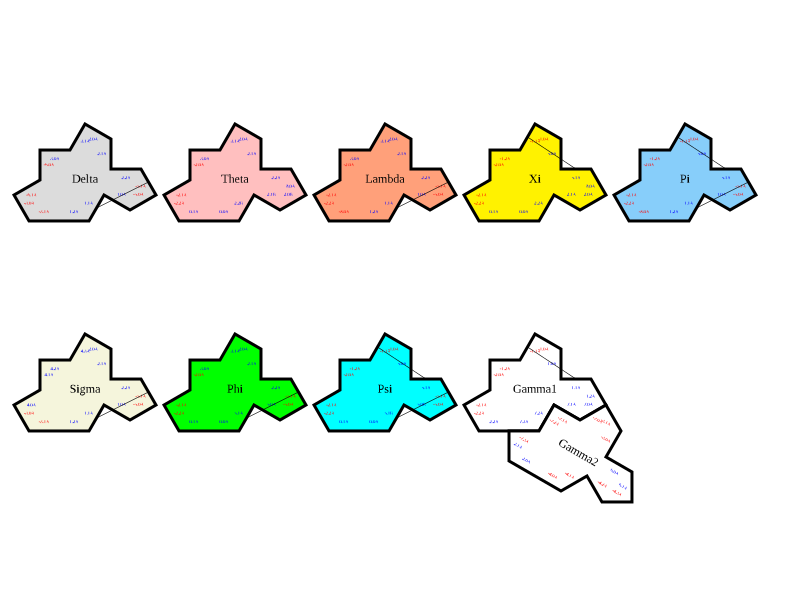

0000000100


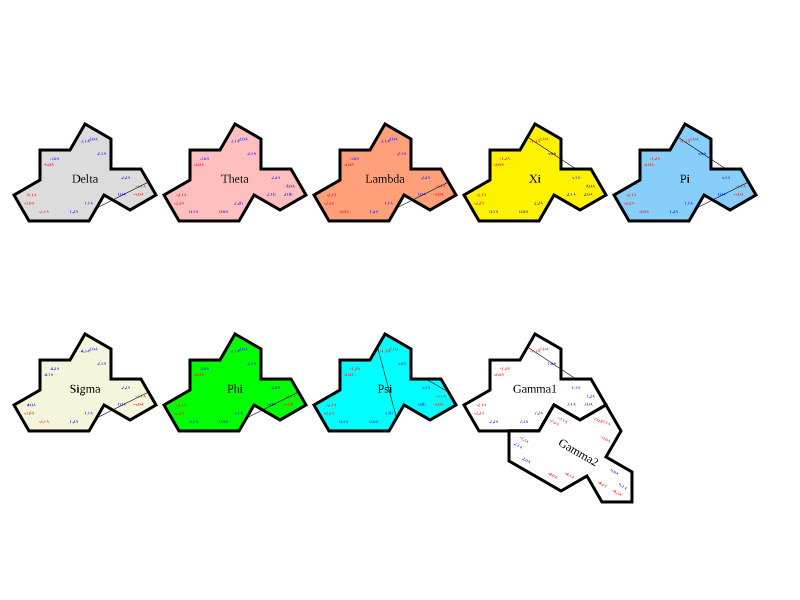

0000100000


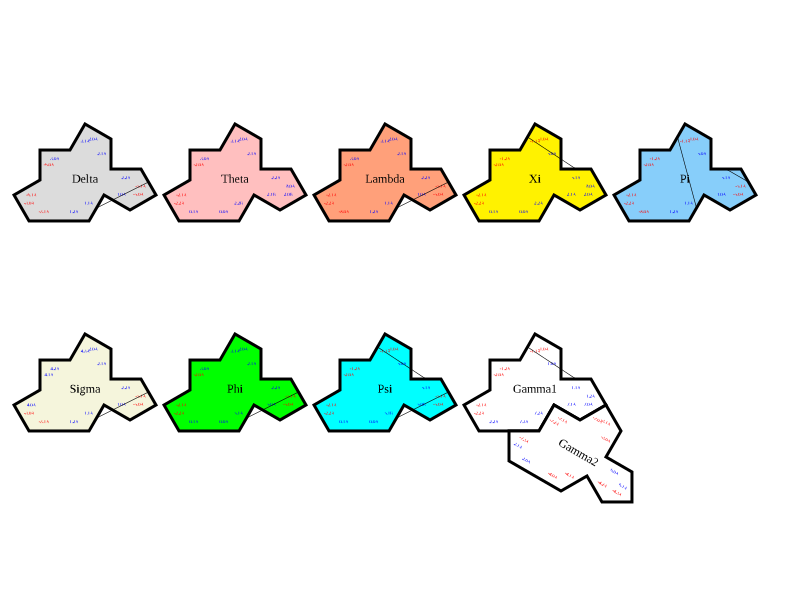

0000100100


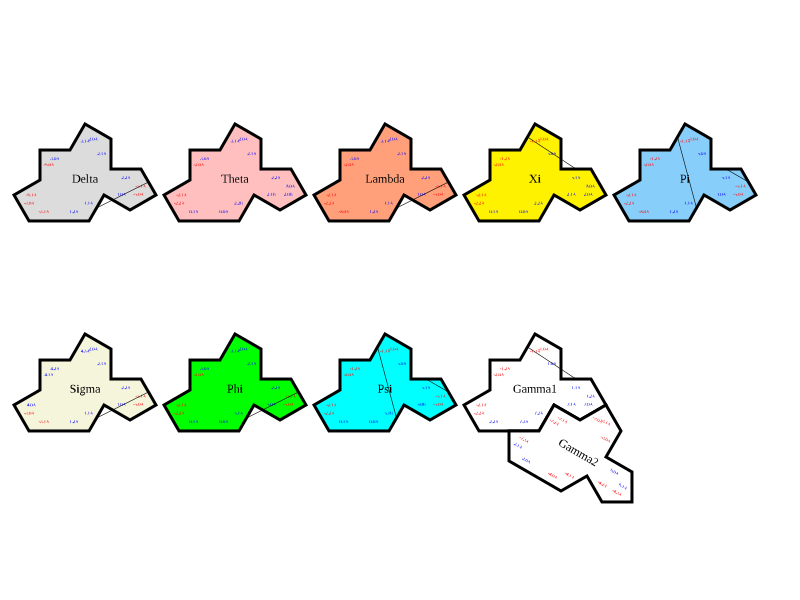

In [34]:
# TODO Show each tile individually. It's hard to see which tile is changing.


all_edges = generate_map_of_valid_combinations([1,5])
# Filter out options where lines cross. These are less interesting and I can come back to them later.
non_crossing_options = filter_non_crossing_combinations(all_edges)
max_options = {t: len(non_crossing_options[t]) for t in ALL_TILE_NAMES}
# Test with first few combinations
for i, combo in enumerate(generate_option_strings(max_options, ALL_TILE_NAMES)):
    print(combo)
    selected_edges = get_edges_from_combo(non_crossing_options, string_to_combo(combo))
    d = draw_tile_grid(draw_funcs=[draw_base, draw_center_text, draw_edge_numbers, draw_specific_edges(selected_edges)])
    display(d)
    if i > 10:  # Print first few for demonstration
        print("...")
        break

In [35]:
for tile in non_crossing_options:
  print(f"{tile}:")
  for combo in non_crossing_options[tile]:
    for pair in combo:
      print(f"* {pair}")
    print()

Delta:
* (Edge(major=5, is_negative=True, minor=1, variant='A', pos=5), Edge(major=1, is_negative=False, minor=1, variant='A', pos=8))

Theta:

Lambda:
* (Edge(major=5, is_negative=True, minor=1, variant='A', pos=5), Edge(major=1, is_negative=False, minor=1, variant='A', pos=8))

Xi:
* (Edge(major=1, is_negative=True, minor=1, variant='A', pos=1), Edge(major=5, is_negative=False, minor=1, variant='A', pos=4))

Pi:
* (Edge(major=1, is_negative=True, minor=1, variant='A', pos=1), Edge(major=5, is_negative=False, minor=1, variant='A', pos=4))
* (Edge(major=5, is_negative=True, minor=1, variant='A', pos=5), Edge(major=1, is_negative=False, minor=1, variant='A', pos=8))

* (Edge(major=1, is_negative=True, minor=1, variant='A', pos=1), Edge(major=1, is_negative=False, minor=1, variant='A', pos=8))
* (Edge(major=5, is_negative=False, minor=1, variant='A', pos=4), Edge(major=5, is_negative=True, minor=1, variant='A', pos=5))

Sigma:
* (Edge(major=5, is_negative=True, minor=1, variant='A', pos=

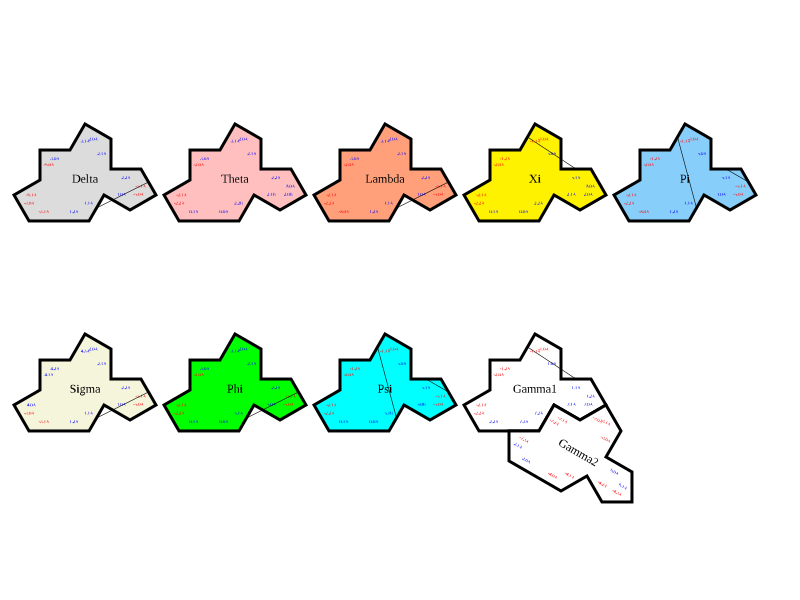

In [36]:

selected_edges = get_edges_from_combo(non_crossing_options, string_to_combo('0000100100'))
d = draw_tile_grid(draw_funcs=[draw_base, draw_center_text, draw_edge_numbers, draw_specific_edges(selected_edges)])
display(d)

# Plotting Edges

See the changes I made to Tile and MetaTile (cmd+shift+G for search in colab). They now generate a graph.

In [37]:
#@title plotting func
import altair as alt
def plot_big_graph_with_components(big_edge_graph, components, focal_coords =None, focal_dist=10, only_render_components=True, add_labels=True, via_center=False):
    alt.data_transformers.enable("vegafusion")
    edge_data = []
    # Create component to color mapping
    component_colors = {}
    for i, comp in enumerate(components):
        for node in comp:
            component_colors[node] = f"{len(comp)}"
    # Process edges with component colors

    plotted_centers = {}
    for p1 in big_edge_graph:
        for p2 in big_edge_graph[p1]:
            if focal_coords and not is_near_focal(p1, focal_coords, focal_dist):
                continue
            comp_num = component_colors.get(p1,0)  # Use component number for color
            if (comp_num == 0 and only_render_components):
                continue
            faces = big_edge_graph[p1][p2]
            mid_x = (p1[0] + p2[0]*0.5) / 1.5
            mid_y = (p1[1] + p2[1]*0.5) / 1.5

            if len(faces) != 1:
              # Unless you're using big_edge_graph .. apparently.
              print(f"Don't think this should happen \nfaces :{faces}")
            extra_offset = 2
            for face_label, edge_pairs in faces.items():
              center = tuple(map(lambda x: float(x), face_label.split(':')[1].strip('()[]').split(',')))
              if via_center:
                c1 = midpoint(pt(*p1), pt(*center))
                c2 = midpoint(pt(*p2), pt(*center))
                edge_data.append({
                    'x1': p1[0], 'y1': p1[1],
                    'x2': c1.xy[0], 'y2': c1.xy[1],
                    'label_x': mid_x ,
                    'label_y': mid_y-extra_offset,
                    'label': f"{face_label.split(':')[0]} {'*'.join([', '.join([str(a) for a in x]) for x in edge_pairs])}",
                    'component': f'Component {comp_num}'
                })
                edge_data.append({
                    'x1':c1.xy[0], 'y2': c1.xy[1],
                    'x2':  c2.xy[0], 'y2': c2.xy[1],
                    'label_x': mid_x ,
                    'label_y': mid_y-extra_offset-2,
                    'label': f"{face_label.split(':')[0]} {'*'.join([', '.join([str(a) for a in x]) for x in edge_pairs])}",
                    'component': f'Component {comp_num}'
                })
                edge_data.append({
                    'x1':  c2.xy[0], 'y2': c2.xy[1],
                    'x2': p2[0], 'y2': p2[1],
                    'label_x': mid_x ,
                    'label_y': mid_y-extra_offset-4,
                    'label': f"{face_label.split(':')[0]} {'*'.join([', '.join([str(a) for a in x]) for x in edge_pairs])}",
                    'component': f'Component {comp_num}'
                })
              else:

                edge_data.append({
                    'x1': p1[0], 'y1': p1[1],
                    'x2': p2[0], 'y2': p2[1],
                    'label_x': mid_x ,
                    'label_y': mid_y-extra_offset,
                    'label': f"{face_label.split(':')[0]} {'*'.join([', '.join([str(a) for a in x]) for x in edge_pairs])}",
                    'component': f'Component {comp_num}'
                })


                extra_offset +=2
                if add_labels:
                  # print(center)
                  # center = tuple(map(float, face_label.split(':')[1].strip('()[]').split(',')))
                  if center not in plotted_centers:
                      plotted_centers[center] = edge_pairs[0]
                      edge_data.append({
                          'x1': center[0], 'y1': center[1],
                          'x2': center[0], 'y2': center[1],
                          'label_x': center[0],
                          'label_y': center[1],
                          'label': face_label.split(':')[0],
                          'type': 'center'
                      })

    df = pd.DataFrame(edge_data)

    edges = alt.Chart(df).mark_line().encode(
        x='x1:Q',
        y='y1:Q',
        x2='x2:Q',
        y2='y2:Q',
        color=alt.Color('component:N')
    )

    labels = alt.Chart(df).mark_text(
        align='center',
        baseline='middle',
        fontSize=8
    ).encode(
        x='label_x:Q',
        y='label_y:Q',
        text='label:N',
        color=alt.Color('component:N')
    )
    to_present = edges
    if add_labels:
      to_present = to_present + labels

    chart = (to_present).properties(
        width=1200,
        height=1200
    ).interactive()

    return chart

In [38]:
shapes = buildSpectreBase()
level = 4
for i in range(level):
  shapes = buildSupertiles(shapes)
big_edge_graph = {}
shapes["Delta"].make_edge_graph(big_edge_graph,allowed_edges=None)

In [39]:
def comps_and_analysis(fg, components):
  leaves, circuits, others = leaves_circuits_other(fg, components)
  unique_comps = {}
  for label, compare_components in [("leaves", leaves), ("circuits", circuits), ("others", others)]:
    unique_comps[label] = []
    print()
    print(f"Graph has {len(compare_components)} *{label}* with sizes:")
    sl = set()
    for i, comp in enumerate(compare_components):
        if len(comp) not in sl:
            unique_comps[label].append(comp)
            print(f"{label} {len(sl)}: {len(comp)} vertices")
            sl.add(len(comp))
  return leaves, circuits, others, unique_comps

In [40]:
max_options = {t: len(non_crossing_options[t]) for t in ALL_TILE_NAMES}
''.join([str(v-1) for v in max_options.values()])

'0000100100'

In [41]:
kernel

{'', '01235678', '0136', '023678', '0356', '1278', '15', '2578'}

In [42]:
for kern_vec in kernel:
  kvs = str_to_set(kern_vec)
  all_edges = generate_map_of_valid_combinations(list(kvs))
  # Filter out options where lines cross. These are less interesting and I can come back to them later.
  non_crossing_options = filter_non_crossing_combinations(all_edges)
  max_options = {t: len(non_crossing_options[t])-1 for t in ALL_TILE_NAMES}
  print(''.join([str(v) for k,v in max_options.items()]), end=', ')
  print(sum([v for k,v in max_options.items()]), end=', ')
  print(','.join([str(x) for x in kvs]))

0000000000, 0, 
0111100001, 5, 8,1,2,7
1000001100, 3, 0,3,5,6
0111101100, 6, 8,2,5,7
4444414411, 31, 0,1,2,3,5,6,7,8
1411001010, 9, 0,2,3,6,7,8
0000100100, 2, 1,5
1000000000, 1, 0,1,3,6


In [43]:
# 1278 - 0100100000 only lines. 0000100000 adds some small circuits. 0110100000 is nice, good for swirls.
# edges_selected = [1,2,7, 8]
edges_selected = [0,2,3,6,7,8]
# combo_selected = "0000000000"# Which option for this selection of edges. Assumes non_crossing filtering and I don't like it in general but it makes it easier to compare graphs so I'll keep it for now.
# combo_selected = "0010100000"
combo_selected = '0401001000'
all_edges = generate_map_of_valid_combinations(edges_selected)
non_crossing_options = filter_non_crossing_combinations(all_edges)
max_options = {t: len(non_crossing_options[t]) for t in ALL_TILE_NAMES}
print(''.join([str(v) for k,v in max_options.items()]), end=', ')
print(string_to_combo(combo_selected))
allowed_edges = get_edges_from_combo(non_crossing_options, string_to_combo(combo_selected))#1200001100

fg = filter_edges(big_edge_graph, allowed_edges)
components = find_components(fg) # components is a list of every path.
leaves, circuits, others, unique_comps = comps_and_analysis(fg, components)
# leaves: Unconnected paths.
# circuits: Connected paths.
# others: e.g. 3 lines meet at a single point, this only occurs in more complex setups.
# unique_comps is a dict of leaves, circuits, others filtered to unique length paths.

### Here is some inspiration for analysis.
# chart = plot_big_graph_with_components(fg, leaves, add_labels=False)#, focal_coords=[(244,-171)]
# chart = plot_big_graph_with_components(fg, unique_comps['circuits'], add_labels=False)#, focal_coords=[(244,-171)]
# chart = plot_big_graph_with_components(fg, [unique_comps['circuits'][1]], add_labels=False, via_center=False)
chart = plot_big_graph_with_components(fg, components, add_labels=False)
chart.interactive()

2522112121, {'Delta': 0, 'Theta': 4, 'Lambda': 0, 'Xi': 1, 'Pi': 0, 'Sigma': 0, 'Phi': 1, 'Psi': 0, 'Gamma2': 0, 'Gamma1': 0}

Graph has 190 *leaves* with sizes:
leaves 0: 19 vertices
leaves 1: 3 vertices
leaves 2: 10 vertices
leaves 3: 8 vertices
leaves 4: 53 vertices
leaves 5: 37 vertices
leaves 6: 30 vertices
leaves 7: 28 vertices
leaves 8: 5 vertices
leaves 9: 35 vertices
leaves 10: 144 vertices
leaves 11: 2 vertices
leaves 12: 14 vertices

Graph has 575 *circuits* with sizes:
circuits 0: 5 vertices
circuits 1: 12 vertices
circuits 2: 14 vertices
circuits 3: 6 vertices
circuits 4: 342 vertices
circuits 5: 54 vertices
circuits 6: 120 vertices

Graph has 0 *others* with sizes:


alt.Chart(...)

In [44]:
# I think this one makes infinite lines.
edges_selected = [2,5,7,8]
combo_selected = "0011001100"
all_edges = generate_map_of_valid_combinations(edges_selected)
non_crossing_options = filter_non_crossing_combinations(all_edges)
allowed_edges = get_edges_from_combo(non_crossing_options, string_to_combo(combo_selected))#1200001100

fg = filter_edges(big_edge_graph, allowed_edges)
components = find_components(fg) # components is a list of every path.
leaves, circuits, others, unique_comps = comps_and_analysis(fg, components)
chart = plot_big_graph_with_components(fg, components, add_labels=False)
chart.interactive()


Graph has 610 *leaves* with sizes:
leaves 0: 4 vertices
leaves 1: 2 vertices
leaves 2: 80 vertices
leaves 3: 23 vertices
leaves 4: 3 vertices
leaves 5: 84 vertices
leaves 6: 78 vertices
leaves 7: 17 vertices
leaves 8: 19 vertices
leaves 9: 866 vertices
leaves 10: 865 vertices
leaves 11: 861 vertices
leaves 12: 81 vertices

Graph has 136 *circuits* with sizes:
circuits 0: 3 vertices

Graph has 0 *others* with sizes:


alt.Chart(...)

# Drawing Spirals

In [45]:
# Lets make an svg but with nice colours.

# Stolen from altair.
tableau10_colors = [
    '#4c78a8',  # blue
    '#f58518',  # orange
    '#e45756',  # red
    '#72b7b2',  # cyan
    '#54a24b',  # green
    '#eeca3b',  # yellow
    '#b279a2',  # purple
    '#ff9da6',  # pink
    '#9d755d',  # brown
    '#bab0ac'   # gray
]

In [46]:
#@title functions for act 2, making swirls.
# hah you thought this was about spectre tiles, this project _by volume_ is actually about handling svg files.
from svgpathtools import parse_path, Path, svg2paths,CubicBezier
from svgpathtools.path import Line
def get_tile_connecting_edges_and_transformed_points():

  points_for_tiles = defaultdict(list)
  og_edges_for_tiles = defaultdict(list)

  edges_selected = range(9)

  tile_edges = create_tile_edges()


  connection_points = [edge.entry_on_spectre() for edge in tile_edges['Gamma2'].connectable_edges()]
  gam2 = transform_points_for_tile(connection_points,mul(ttrans(SPECTRE_POINTS[8].x, SPECTRE_POINTS[8].y), trot(np.pi/6)))

  og_edges_for_tiles['Gamma2'] = tile_edges['Gamma2'].connectable_edges()
  for pi, point in enumerate(gam2):
      transformed_point = apply_transform(point, get_tile_transforms()["Gamma"])
      points_for_tiles['Gamma2'].append(transformed_point)



  connection_points = [edge.entry_on_spectre() for edge in tile_edges['Gamma1'].connectable_edges()]
  og_edges_for_tiles['Gamma1'] = tile_edges['Gamma1'].connectable_edges()
  for point in connection_points:
      transformed_point = apply_transform(point, get_tile_transforms()["Gamma"])
      points_for_tiles['Gamma1'].append(transformed_point)


  for tile_name, edges in tile_edges.items():
    if 'Gamma' in tile_name:
      continue
    connection_points = [edge.entry_on_spectre() for edge in edges.connectable_edges()]
    og_edges_for_tiles[tile_name] = edges.connectable_edges()
    for point in connection_points:
        transformed_point = apply_transform(point, get_tile_transforms()[tile_name])
        points_for_tiles[tile_name].append(transformed_point)
  return points_for_tiles, og_edges_for_tiles

def draw_specific_edges_color_comp(spec_edges, comps):
    c_len_local = defaultdict(lambda x: 0)
    for comp in comps:
      l = len(comp) % len(tableau10_colors)
      for pair in comp:
        # p_check = (round(pair[0],1), round(pair[1],1))
        c_len_local[pair] = l

    def point_to_colour_local(pt):
      # p_check = (round(pt.x*10,1), round(pt.y*10,1))
      p_check = (round(pt.x*10,3), round(pt.y*10,3))
      # print(p_check)
      if p_check in c_len_local:
        return tableau10_colors[c_len_local[p_check]]
      return "black"
    def inner(group, label, T):

        ae = spec_edges[label]
        for p1i,p2i in ae:
            p1 = SPECTRE_POINTS[p1i.pos]
            if p1i.major != 0:
                p1 = midpoint(p1, SPECTRE_POINTS[(p1i.pos + 1) % len(SPECTRE_POINTS)])
            p2 = SPECTRE_POINTS[p2i.pos]
            if p2i.major != 0:
                p2 = midpoint(p2, SPECTRE_POINTS[(p2i.pos + 1) % len(SPECTRE_POINTS)])
            p1_global = transPt(T, p1)
            col  = point_to_colour_local(p1_global)
            if col == "black":
              p2_global = transPt(T, p2)
              col  = point_to_colour_local(p2_global)

            # print(p1_global.xy)
            group.append(draw.Line(
                p1.x, p1.y,
                p2.x, p2.y,
                stroke=col,
                stroke_width=0.2
            ))
    return inner


def draw_from_state(TILE_DRAWINGS, comps = None):
    """Draw elements for a specific tile type from TILE_DRAWINGS with component coloring"""
    stroke = 'black'
    c_len_local = defaultdict(lambda x: 0)
    if comps:
      for comp in comps:
        l = len(comp) % len(tableau10_colors)
        for pair in comp:

          # p_check = (round(pair[0],1), round(pair[1],1))
          c_len_local[pair] = l

    def point_to_colour_local(pt):
      p_check = (round(pt.x*10,3), round(pt.y*10,3))
      if p_check in c_len_local:
        return tableau10_colors[c_len_local[p_check]]
      return "black"
    def inner(group, label, T):
      for element in TILE_DRAWINGS.get(label, []):
          if element['type'] == 'dot':

              p1_global = transPt(T, pt(element['pos'][0], element['pos'][1]))
              col = point_to_colour_local(p1_global)
              if 'color' in element:
                col = element['color']
              group.append(draw.Circle(
                  element['pos'][0], element['pos'][1],
                  0.1,
                  fill=col
              ))
              group.append(draw.Text(
                  element['label'],
                  0.2,
                  element['pos'][0], element['pos'][1] - 0.2,
                  text_anchor="middle",
                  fill=col
              ))
          elif element['type'] == 'line':
              group.append(draw.Line(
                  element['start'][0], element['start'][1],
                  element['end'][0], element['end'][1],
                  stroke=stroke,
                  stroke_width=0.05
              ))
          elif element['type'] == 'object':
              group.append(element['object'])
          elif element['type'] == 'func':
              ret = element['func']()
              if 'pos4color' in element:
                pos = element['pos4color']
                p1_global = transPt(T, pos)
                col = point_to_colour_local(p1_global)
                ret.args['stroke']= col
              group.append(ret)
    return inner

def add_dot_to_tile(tile_type, point, label, color = None):
    """Add a dot with label to a tile at the given point."""
    a = {
        'type': 'dot',
        'pos': point.xy,
        'label': label,
    }
    if color is not None:
      a['color'] = color
    TILE_DRAWINGS[tile_type].append(a)

def add_line_to_tile(tile_type, start, end):
   """Add a line to a tile between two points."""
   TILE_DRAWINGS[tile_type].append({
       'type': 'line',
       'start': start.xy,
       'end': end.xy
   })

def draw_dots_for_edge(major, inset=0):
    """Draw dots for all tiles containing edges matching the major."""
    matching_tiles = find_tiles_with_edge_major(major)
    for tile_type in matching_tiles:
        points = find_edge_points(tile_type, major, inset)
        for point in points:
            add_dot_to_tile(tile_type, point, str(major))  # Use first character of major as label


def find_tiles_with_edge_major(major):
    """Find all tiles that have edges matching the given major."""
    return {t for t, es in create_tile_edges().items() if es.with_majors([major]).edges}



def find_edge_points(tile_type, major, inset=0):
  """Find points corresponding to edges matching the major in a tile."""
  edge_labels = get_edge_labels(tile_type)
  indices = [i for i, e in enumerate(edge_labels) if e.major == major]
  points = []
  for e in edge_labels.with_majors([major]).connectable_edges():
    p1 = SPECTRE_POINTS[e.pos]
    if e.major != 0:
      p1 = midpoint(p1,SPECTRE_POINTS[(e.pos + 1) % len(SPECTRE_POINTS)])
    points.append(p1)
  return points







def analyze_svg_diff(original, modified):
   orig_paths, orig_attrs, orig_svg_attrs = svg2paths(original, return_svg_attributes=True)
   mod_paths, mod_attrs, mod_svg_attrs = svg2paths(modified, return_svg_attributes=True)

   # Get IDs from both files
   orig_ids = {attr.get('id') for attr in orig_attrs if attr.get('id')}
   mod_ids = {attr.get('id') for attr in mod_attrs if attr.get('id')}

   new_ids = mod_ids - orig_ids
  #  print(new_ids)

   new_paths = []
   for path, attr in zip(mod_paths, mod_attrs):
       if attr.get('id') in new_ids:
           new_paths.append((path,attr))

   return new_paths



def points_for_line(new_line):
  """get the start and end points for this line object"""
  matrix = None
  if 'transform' in new_line.args and 'matrix(' in new_line.args['transform']:
    matrix = parse_matrix_transform(*[float(x) for x in new_line.args['transform'][len('matrix('):-1].split(',')]) #parse_matrix_transform(30, 0, 0, 30, -360, -150)
  return get_transformed_start_end_points(new_line.args['d'], matrix)

def get_new_lines(mods):
    rets = []
    for path,attrs in mods:
        style = attrs.get('style', '')
        stroke_width = '1'
        if 'stroke-width' in style:
            stroke_width = style.split('stroke-width:')[1].split(';')[0]  # Extract stroke width from style
            if 'px' in stroke_width:
                stroke_width = stroke_width.replace('px', '')
        tx = attrs['transform'] if 'transform' in attrs else ''
        new_line = draw.Path(d=path.d(), fill='none', stroke='purple', stroke_width=stroke_width, transform=tx)
        rets.append(new_line)
    return rets




def apply_matrix_to_point(point, matrix):
    """ Apply a transformation matrix to a point """
    transformed_point = np.dot(matrix, [point.real, point.imag, 1])
    return complex(transformed_point[0], transformed_point[1])


def apply_matrix_to_path(path, matrix):
    """ Apply a transformation matrix to each point in the path """
    transformed_segments = []
    for segment in path:
        print(type(segment))
        if isinstance(segment, Line):
            start = apply_matrix_to_point(segment.start, matrix)
            end = apply_matrix_to_point(segment.end, matrix)
            transformed_segments.append(Line(start, end))
        elif isinstance(segment, CubicBezier):
            start = apply_matrix_to_point(segment.start, matrix)
            control1 = apply_matrix_to_point(segment.control1, matrix)
            control2 = apply_matrix_to_point(segment.control2, matrix)
            end = apply_matrix_to_point(segment.end, matrix)
            transformed_segments.append(CubicBezier(start, control1, control2, end))
        else:
            # Add additional segment types as needed
            transformed_segments.append(segment)  # Default placeholder
    return Path(*transformed_segments)

def get_transformed_start_end_points(path_d, matrix=None):
    path = parse_path(path_d)
    if matrix is None:
      start_point = pt(path[0].start.real, path[0].start.imag)
      end_point = pt(path[-1].end.real, path[-1].end.imag)
      return start_point, end_point

    transformed_path = apply_matrix_to_path(path, matrix)
    start_point = pt(transformed_path[0].start.real, transformed_path[0].start.imag)
    end_point = pt(transformed_path[-1].end.real, transformed_path[-1].end.imag)
    return start_point, end_point

# Function to apply transformation matrix to a point
def apply_transform(point, matrix):
    # x, y = point
    transformed_x = matrix[0]*point.x + matrix[1]*point.y + matrix[2]
    transformed_y = matrix[3]*point.x + matrix[4]*point.y + matrix[5]
    return pt(transformed_x, transformed_y)

def transform_points_for_tile(points, transform):
    """Transform a list of points using an affine transform matrix"""
    transformed_points = []
    for point in points:
        x = transform[0]*point.x + transform[1]*point.y + transform[2]
        y = transform[3]*point.x + transform[4]*point.y + transform[5]
        transformed_points.append(pt(x, y))
    return transformed_points

# Function to draw transformed points for each tile type
def draw_transformed_points(drawing, points, transforms):
    for tile_type, transform in transforms.items():
        for point in points:
            transformed_point = apply_transform((point.x, point.y), transform)
            # Draw a circle at the transformed point
            drawing.append(draw.Circle(
                transformed_point.x, transformed_point.y, 4,
                fill='none', stroke=COLOR_MAP.get(tile_type, "black"), stroke_width=0.6
            ))



def find_matching_point_indices(point, transformed_points, threshold=4):
    return [i for i, tp in enumerate(transformed_points)
            if pt_distance(point, tp) <= threshold]

def get_gamma2_points():
    # gamma2_transform = mul(ttrans(SPECTRE_POINTS[8].x, SPECTRE_POINTS[8].y), trot(np.pi/6))
    return points_for_tiles['Gamma2'] #transform_points_for_tile(SPECTRE_POINTS, gamma2_transform)

def check_tile_match(start_point, end_point, tile_type, transform):
    points = points_for_tiles[tile_type]#transform_points_for_tile(SPECTRE_POINTS, transform)
    start_matches = find_matching_point_indices(start_point, points)
    end_matches = find_matching_point_indices(end_point, points)

    if start_matches and end_matches:
        return {
            'tile': tile_type,
            'start_idx': start_matches[0],
            'end_idx': end_matches[0]
        }
    return None

def check_gamma2_match(start_point, end_point, gamma_transform):
    gamma2_points = get_gamma2_points()
    transformed_gamma2 = points_for_tiles['Gamma2'] #transform_points_for_tile(gamma2_points, gamma_transform)
    start_matches = find_matching_point_indices(start_point, transformed_gamma2)
    end_matches = find_matching_point_indices(end_point, transformed_gamma2)

    if start_matches and end_matches:
        return {
            'tile': 'Gamma2',
            'start_idx': start_matches[0],
            'end_idx': end_matches[0]
        }
    return None

def match_line_to_tile(start_point, end_point):
    transforms = get_tile_transforms()
    matches = []
    bad_edges = []

    # Check regular tiles
    for tile_type, transform in transforms.items():
        t_match = check_tile_match(start_point, end_point,
                               'Gamma1' if tile_type == 'Gamma' else tile_type,
                               transform)
        if t_match:
            matches.append(t_match)

    # Check Gamma2 separately
    gamma2_match = check_gamma2_match(start_point, end_point, transforms['Gamma'])
    if gamma2_match:
        matches.append(gamma2_match)

    if not matches:
        # If the image looks fine you can probably ignore any of these.
        # Inkscape might just add some stuff depending on what drawPolygon is doing.
        if start_point.xy == end_point.xy:
          print(f'Error unexpected dot detected {start_point.xy}')
        else:
          print(f"Error: Line from {start_point.xy} to {end_point.xy} doesn't match any tile")
        bad_edges.append((start_point, end_point))

    return matches, bad_edges




def create_TILE_DRAWINGS_from_mods(mods,points_for_tiles):
  TILE_DRAWINGS = defaultdict(list)
  transforms = get_tile_transforms()
  found_edges = defaultdict(list)
  for new_line in get_new_lines(mods):
      start_point, end_point = multi_points_for_line(new_line,points_for_tiles)
      if start_point is None or end_point is None:
        continue
      matches, _ = match_line_to_tile(start_point, end_point)
      if len(matches) >1:
        print(f"warning multiple matches {matches}")
        continue
      if len(matches) == 0:
        continue
      t_match = matches[0]
      tile_type = t_match['tile']
      transform = transforms['Gamma'] if tile_type in ['Gamma1', 'Gamma2'] else transforms[tile_type]

      # tile_type

      # Apply inverse transform to points
      inv_transform = invert_transform(transform)
      start_edge = og_edges_for_tiles[tile_type][t_match['start_idx']]
      end_edge = og_edges_for_tiles[tile_type][t_match['end_idx']]
      if start_edge == end_edge:
        print(f"Invalid path for {tile_type}. Path stats and ends at {start_edge}")
        continue
      found_edges[tile_type].append([start_edge, end_edge])
      sp = og_edges_for_tiles[tile_type][t_match['start_idx']].entry_on_spectre()
      ep = og_edges_for_tiles[tile_type][t_match['end_idx']].entry_on_spectre()


      # This is a horendous abuse of closure, but the code over here has all the stuff we need
      # and we need to get it all the way over to rendering in drawPolygon and I tried just passing around
      # a draw.Path() obj but I couldn't modify it because idk it was being reused or something and the
      # colours were wrong.
      def make_make_line(sp_local,ep_local,inv_transform_local,new_line_local,start_point_local, end_point_local,transform_local):
        fix_mat = align_edge(start_point_local, end_point_local, transPt(transform_local,sp_local),transPt(transform_local,ep_local))
        fin_trans = mul(inv_transform_local,fix_mat)
        def make_line():
          # Copy transform and attributes from new_line_local
          line_obj = draw.Path(
              d=new_line_local.args['d'],
              # Examples of how to extract features from the svg.
              fill=new_line_local.args.get('fill', 'none'),
              # stroke=new_line_local.args.get('stroke', 'white'),
              stroke='blue', # This will get overriden with a colour based on the component the line is in.
              stroke_width=2,#new_line_local.args.get('stroke-width', '0.5'),
              transform=f"matrix({fin_trans[0]} {fin_trans[3]} {fin_trans[1]} {fin_trans[4]} {fin_trans[2]} {fin_trans[5]})"
          )
          return line_obj
        return make_line

      if tile_type not in TILE_DRAWINGS:
          TILE_DRAWINGS[tile_type] = []

      TILE_DRAWINGS[tile_type].append({
          'type': 'func',
          'pos4color':sp,
          'pos4colore':ep,
          'func': make_make_line(sp,ep,inv_transform,new_line,start_point, end_point,transform),
      })
  return TILE_DRAWINGS, found_edges

In [47]:

d = draw_tile_grid(draw_funcs=[

    draw_base,
    draw_center_text,
    draw_edge_numbers,
    draw_specific_edges(allowed_edges),
])
save_drawing(d, '2578-0100101100')

'<?xml version="1.0" encoding="UTF-8"?>\n<svg xmlns="http://www.w3.org/2000/svg" xmlns:xlink="http://www.w3.org/1999/xlink"\n     width="800" height="600" viewBox="-400.0 -300.0 800 600">\n<defs>\n<path d="M0,0 L1.0,0.0 L1.5,-0.8660254037844386 L2.3660254037844384,-0.3660254037844386 L2.3660254037844384,0.6339745962155614 L3.3660254037844384,0.6339745962155614 L3.8660254037844384,1.5 L3.0,2.0 L2.1339745962155616,1.5 L1.6339745962155614,2.3660254037844384 L0.6339745962155614,2.3660254037844384 L-0.3660254037844386,2.3660254037844384 L-0.8660254037844386,1.5 L0.0,1.0 Z" id="d0" />\n</defs>\n<g transform="matrix(30.0 0.0 0.0 30.0 -360.0 -150.0)">\n<use xlink:href="#d0" x="0" y="0" fill="rgb(220, 220, 220)" stroke="black" stroke-width="0.1" />\n<text x="1.5" y="1.0" font-size="0.4" text-anchor="middle" fill="black" dominant-baseline="middle">Delta</text>\n<text x="0.5" y="0.3" font-size="0.15" text-anchor="middle" fill="blue" dominant-baseline="middle">3.0A</text>\n<text x="1.5098076211353


Graph has 190 *leaves* with sizes:
leaves 0: 19 vertices
leaves 1: 3 vertices
leaves 2: 10 vertices
leaves 3: 8 vertices
leaves 4: 53 vertices
leaves 5: 37 vertices
leaves 6: 30 vertices
leaves 7: 28 vertices
leaves 8: 5 vertices
leaves 9: 35 vertices
leaves 10: 144 vertices
leaves 11: 2 vertices
leaves 12: 14 vertices

Graph has 575 *circuits* with sizes:
circuits 0: 5 vertices
circuits 1: 12 vertices
circuits 2: 14 vertices
circuits 3: 6 vertices
circuits 4: 342 vertices
circuits 5: 54 vertices
circuits 6: 120 vertices

Graph has 0 *others* with sizes:


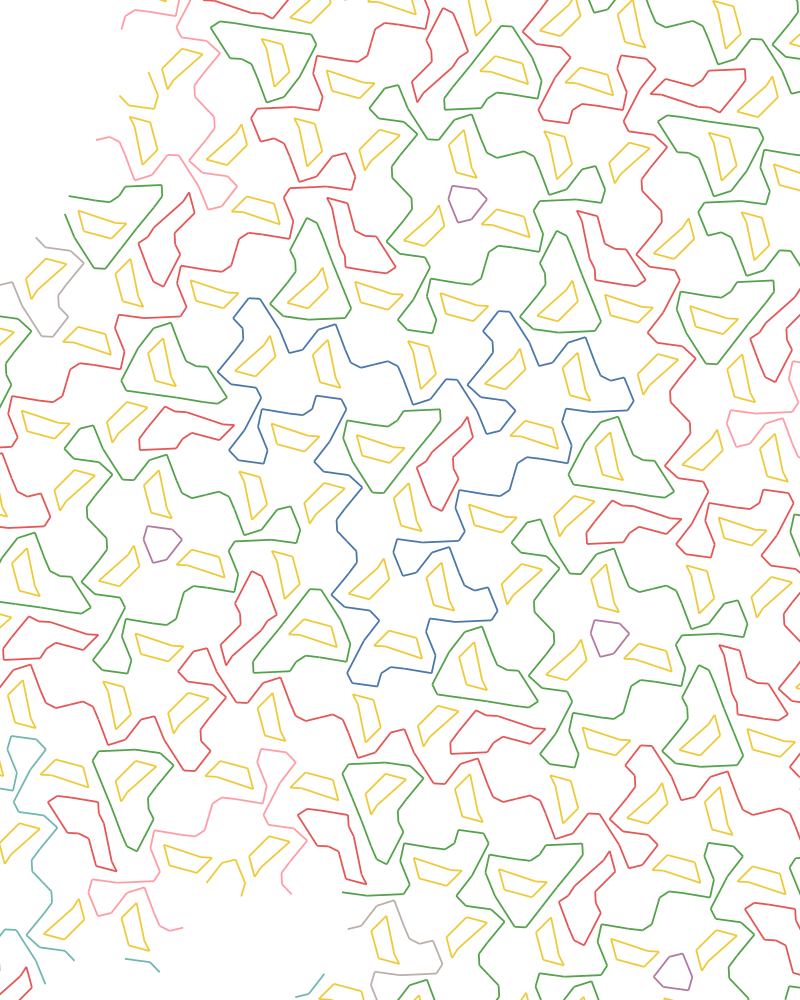

In [48]:
# I think this one makes infinite lines.
# edges_selected = [2,5,7,8]
# combo_selected = "0100101100"
# edges_selected = [2,1,7,8]
# combo_selected = "0010100000"

edges_selected = [0,2,3,6,7,8]
combo_selected = '0401001000'
all_edges = generate_map_of_valid_combinations(edges_selected)
non_crossing_options = filter_non_crossing_combinations(all_edges)
allowed_edges = get_edges_from_combo(non_crossing_options, string_to_combo(combo_selected))#1200001100

fg = filter_edges(big_edge_graph, allowed_edges)
components = find_components(fg) # components is a list of every path.
leaves, circuits, others, unique_comps = comps_and_analysis(fg, components)


# Draw straight lines to svg instead of plotting them.
w = 800
h = 1000
d = draw.Drawing(w, h, origin="center")
d.append(draw.Rectangle(-w/2, -h/2, w, h, fill='white'))

shapes["Delta"].draw(d, draw_funcs=[

    # draw_base,
    # draw_center_text,
    # draw_edge_numbers,
    draw_specific_edges_color_comp(allowed_edges, components),
])
d =scale_drawing(d, 9, offset=(-500,570))
d

This is pretty cool, and I have had a lot of fun exploring different configurations but I'd like to make some swirls.

In [ ]:
m = draw_big_tile_grid(draw_funcs=[
    draw_base,
    draw_center_text,
    draw_edge_numbers,
    # draw_from_state(TILE_DRAWINGS),
    draw_specific_edges(allowed_edges),
])
save_drawing(m, 'ref_together')

In [ ]:
# Then define the individual drawing functions:
def draw_feather(group, label, _):
    group.append(draw.Use(
        SPECTRE_SHAPE,
        0, 0,
        fill=COLOR_MAP[label],
        stroke="black",
        stroke_width=0.1))

In [ ]:
#@title Template Generator

d = draw_tile_grid(draw_funcs=[
    draw_base,
    draw_center_text,
    draw_edge_numbers,
    # draw_from_state(TILE_DRAWINGS),
    # draw_specific_edges(allowed_edges),# comment out for ref
])


# Make a dict of points in the reference image for each tile.
points_for_tiles,og_edges_for_tiles= get_tile_connecting_edges_and_transformed_points()

for tile_name, points in points_for_tiles.items():
  for transformed_point in points:
      d.append(draw.Circle(
          transformed_point.x, transformed_point.y, 4,
          fill='none', stroke='black', stroke_width=0.6 #COLOR_MAP.get(tile_name, "black")
      ))


# edges_selected = [0,2,3,6,7,8]
# # combo_selected = "0000000000"# Which option for this selection of edges. Assumes non_crossing filtering and I don't like it in general but it makes it easier to compare graphs so I'll keep it for now.
# # combo_selected = "0010100000"
# combo_selected = '0401001000'
save_drawing(d, f'ref_{"".join([str(x) for x in edges_selected])}_{combo_selected}')
d

# Download the generated image.
# Open in inkscape.
# Save it (this will modify things).
# Draw your own lines between points and save a copy.
# Upload both versions.

In [ ]:
#@title check that it's got the lines.

# mod_file = '/content/ref_clear_mod_bo_miser.svg'
# ref_file = '/content/ref_clear_new.svg'

ref_file = '/content/aref_023678_0401001000.svg'
mod_file = '/content/ref_023678_0401001000 feathers copy.svg'

mods = analyze_svg_diff(ref_file,mod_file)

d = draw_tile_grid(draw_funcs=[
    draw_base, # We can add this back in. It was playing havoc for me in inkscape so I removed it earlier.
    draw_center_text,
    draw_edge_numbers,
    # draw_from_state(TILE_DRAWINGS),
    # draw_specific_edges(allowed_edges),
])

def multi_points_for_line(new_line,points_for_tiles):
  """get the start and end points for this line object"""
  matrix = None
  if 'transform' in new_line.args and 'matrix(' in new_line.args['transform']:
    matrix = parse_matrix_transform(*[float(x) for x in new_line.args['transform'][len('matrix('):-1].split(',')]) #parse_matrix_transform(30, 0, 0, 30, -360, -150)
  return get_transformed_multi_points(new_line.args['d'],points_for_tiles, matrix=matrix)
def get_transformed_multi_points(path_d,points_for_tiles,dist=4, matrix=None):
    print(f"dist {dist}")
    path = parse_path(path_d)
    if matrix is not None:
      path = apply_matrix_to_path(path, matrix)
    points_touching_dict = defaultdict(list)
    # TODO update to handle telling which tiles a thing touches.
    for tile, tile_points in points_for_tiles.items():
      for goal_point in tile_points:
        for point in path:
          for sp in [point.start, point.end]:
            a_point = pt(sp.real, sp.imag)
            if pt_distance(goal_point, a_point) < dist: # magic number
              points_touching_dict[tile].append(a_point)
    if len(points_touching_dict.keys()) >1:
      print(f"found matches for 2 or more tiles {points_touching_dict.keys()}")
    for found_tile,points_touching in points_touching_dict.items():
      if len(points_touching) < 2:
        print(f"Didn't find enough points, {found_tile} found {len(points_touching)} {len(path)} {path}")
        # start_point = pt(path[0].start.real, path[0].start.imag)
        # end_point = pt(path[-1].end.real, path[-1].end.imag)
        # return start_point, end_point
        # Give garbage.
        # return pt(path[0].start.real, path[0].start.imag), pt(path[-1].start.real, path[-1].start.imag)
      elif len(points_touching) > 2:
        print(f"Too many contact points,{found_tile} found {len(points_touching)} trying with smaller dist {dist}")
        return get_transformed_multi_points(path_d,points_for_tiles,dist=dist*3/4, matrix=matrix)
    # else:
    #   print(f"found {len(points_touching)} {path}")
      if len(points_touching)== 2:
        return points_touching[0], points_touching[-1]
    print("Failed for all tiles")
    return None, None


# This just draws them over the same space as the tiles. We need to work out where these lines start and end
# What tile they are in, and what edge.
for new_line in get_new_lines(mods):
    d_def = parse_path(new_line.args['d'])

    start_point, end_point = multi_points_for_line(new_line, points_for_tiles)
    if start_point is None or end_point is None:
      continue
    d.append(new_line)
    d.append(draw.Circle(start_point.x, start_point.y, 2, fill='red'))
    d.append(draw.Circle(end_point.x, end_point.y, 2, fill='blue'))




for tile_name, points in points_for_tiles.items():
  for transformed_point in points:
      d.append(draw.Circle(
        transformed_point.x, transformed_point.y, 4,
          fill='none', stroke='black', stroke_width=0.6 #COLOR_MAP.get(tile_name, "black")
      ))
# save_drawing(d,'ref_bo')
d



In [ ]:
#@title load update
# Update TILE_DRAWINGS with new lines
mods = analyze_svg_diff(ref_file, mod_file)
TILE_DRAWINGS, found_edges =  create_TILE_DRAWINGS_from_mods(mods,points_for_tiles)
# If everything looks right in the image, you can ignore the errors. The saving to inkscape process seems to add random things, or maybe there's a bug here somewhere idk.
d = draw_tile_grid(draw_funcs=[
    draw_base,
    draw_center_text,
    draw_edge_numbers,
    draw_from_state(TILE_DRAWINGS),
    draw_specific_edges(found_edges), # Check that there's a thin line between the edges you intended to join.

    draw_specific_edges(allowed_edges),# comment out for ref
    # draw_specific_edges(allowed_edges),
])
d

In [ ]:
# Analyse the edges from your drawing.
fg = filter_edges(big_edge_graph, found_edges)
components = find_components(fg) # components is a list of every path.
leaves, circuits, others, unique_comps = comps_and_analysis(fg, components)

In [ ]:
# 1278 - 0100100000 only lines. 0000100000 adds some small circuits. 0110100000 is nice, good for swirls.
# edges_selected = [1,2,7,# 8]
# combo_selected = "0110100000"# Which option for this selection of edges. Assumes non_crossing filtering and I don't like it in general but it makes it easier to compare graphs so I'll keep it for now.
all_edges = generate_map_of_valid_combinations(edges_selected)
non_crossing_options = filter_non_crossing_combinations(all_edges)
allowed_edges = get_edges_from_combo(non_crossing_options, string_to_combo(combo_selected))#1200001100

fg = filter_edges(big_edge_graph, allowed_edges)
components = find_components(fg) # components is a list of every path.
leaves, circuits, others, unique_comps = comps_and_analysis(fg, components)
chart = plot_big_graph_with_components(fg, components, add_labels=False)
chart.interactive()

In [ ]:
save_drawing(d, 'elegant_big')

In [ ]:
#@title Create your swirls
w = 800
h = 1000
d = draw.Drawing(w, h, origin="center")
d.append(draw.Rectangle(-w/2, -h/2, w, h, fill='white'))

# shapes["Delta"].draw(d, draw_funcs=[draw_specific_edges_color_comp(allowed_edges, circuits)])
# shapes["Delta"].draw(d, draw_funcs=[
#     draw_base,
#     draw_center_text,
# #     draw_edge_numbers,
# #     # draw_specific_edges_color_comp(found_edges, components), # Verify things are working.
# #     # draw_from_state(TILE_DRAWINGS, components),
# ])
shapes["Delta"].draw(d, draw_funcs=[
    # draw_base,
    # draw_center_text,
    # draw_edge_numbers,
    # draw_specific_edges_color_comp(found_edges, components), # Verify things are working.
    draw_from_state(TILE_DRAWINGS, components),
])
d =scale_drawing(d, 10, offset=(-50*2,57*2))
# save_drawing(d, 'bo_l2')
d

In [ ]:
#@title Create your swirls
w = 800
h = 1000
d = draw.Drawing(w, h, origin="center")
d.append(draw.Rectangle(-w/2, -h/2, w, h, fill='white'))

# shapes["Delta"].draw(d, draw_funcs=[draw_specific_edges_color_comp(allowed_edges, circuits)])
# shapes["Delta"].draw(d, draw_funcs=[
#     draw_base,
#     draw_center_text,
# #     draw_edge_numbers,
# #     # draw_specific_edges_color_comp(found_edges, components), # Verify things are working.
# #     # draw_from_state(TILE_DRAWINGS, components),
# ])
shapes["Delta"].draw(d, draw_funcs=[
    # draw_base,
    # draw_center_text,
    # draw_edge_numbers,
    # draw_specific_edges_color_comp(found_edges, components), # Verify things are working.
    draw_from_state(TILE_DRAWINGS, components),
])
d =scale_drawing(d, 30, offset=(-50*2,57*2))
# save_drawing(d, 'bo_l2')
d

In [ ]:
#@title Create your swirls
w = 800
h = 1000
d = draw.Drawing(w, h, origin="center")
d.append(draw.Rectangle(-w/2, -h/2, w, h, fill='white'))

shapes["Delta"].draw(d, draw_funcs=[draw_specific_edges_color_comp(allowed_edges, circuits)])
# shapes["Delta"].draw(d, draw_funcs=[
#     draw_base,
#     draw_center_text,
# #     draw_edge_numbers,
# #     # draw_specific_edges_color_comp(found_edges, components), # Verify things are working.
# #     # draw_from_state(TILE_DRAWINGS, components),
# ])
shapes["Delta"].draw(d, draw_funcs=[
    # draw_base,
    # draw_center_text,
    # draw_edge_numbers,
    # draw_specific_edges_color_comp(found_edges, components), # Verify things are working.
    draw_from_state(TILE_DRAWINGS, components),
])
d =scale_drawing(d, 5, offset=(-50*2,57*2))
# save_drawing(d, 'bo_l2')
d

In [ ]:

shapes["Delta"].draw(d, draw_funcs=[draw_specific_edges_color_comp(allowed_edges, circuits)])
shapes["Delta"].draw(d, draw_funcs=[
    draw_base,
    draw_center_text,
    draw_edge_numbers,
    # draw_specific_edges_color_comp(found_edges, components), # Verify things are working.
    # draw_from_state(TILE_DRAWINGS, components),
])
d

In [ ]:
# Save your art.
save_drawing(d, 'long_line_wriggles')
print()

In [ ]:
# Analyse the edges you chose.
chart = plot_big_graph_with_components(fg, components, add_labels=False)#, focal_coords=[(920,330)], focal_dist=100)
chart.interactive()